# Prediksi Tinggi Muka Air (TMA) Bengawan Solo
## Sebelas Maret Statistics & Data Science Competition 2026

**Tim:** Thoriq Uner

**Kampus:** Universitas Negeri Surabaya (UNESA)

---

Notebook ini (**Bagian 1: EDA**) menyajikan eksplorasi data sebelum masuk ke tahap modeling (Bagian 2), untuk memprediksi **Tinggi Muka Air (`tma_mdpl`)** di 30 pos pemantauan DAS Bengawan Solo berdasarkan data historis dan variabel eksogen (curah hujan, kelembapan tanah, tekanan udara, indeks iklim global).

### Gambaran Masalah
- **Dataset**: BBWS Bengawan Solo, 30 pos pemantauan, data historis TMA (3x sehari: 06.00/12.00/18.00) + fitur eksogen dari `data_lingkungan.csv`
- **Target**: `tma_mdpl` (regresi) horizon prediksi test 241 hari (~8 bulan) ke depan, nempel langsung ke akhir data train
- **Tantangan utama**: skala TMA beda jauh antar pos, ada sensor glitch (spike ekstrem satu-titik yang perlu dibersihkan), horizon prediksi panjang tanpa ground truth di antaranya
- **Metrik evaluasi**: RMSE (Root Mean Squared Error)

### Pendekatan (detail lengkap di Bagian 2: Modeling)
| Komponen | Peran |
|---|---|
| **Baseline musiman (harmonic/Fourier)** | Nangkep pola musiman per pos; sisanya (`anomaly`) yang diprediksi model |
| **LightGBM** | Model utama, hyperparameter (termasuk `objective`) dituning pakai Optuna |
| **Stage B (upstream)** | Fitur tambahan dari pos "hulu" terdekat, weighted multi-candidate |
| **Persistence decay blend** | Manfaatin TMA terakhir yang diketahui, makin jauh horizon makin di-decay |

### Struktur Notebook (Bagian 1: EDA)
| # | Judul |
|---|---|
| 1 | Load Data |
| 2 | Kelengkapan Data per Pos |
| 3 | Skala TMA Beda-beda Tiap Pos |
| 4 | Deteksi Outlier Ekstrem per Pos |
| 5 | Contoh Time Series Pos Stabil vs Pos Fluktuatif |
| 6 | Pola Musiman |
| 7 | Korelasi TMA dengan Fitur Eksogen |
| 8 | Sebaran Lokasi 30 Pos |
| 9 | Indeks Iklim Global (Niño 3.4 & MJO) |
| 10 | Skala TMA vs Keadilan Metric RMSE |
| 11 | Korelasi dengan Lag Curah Hujan & Soil Moisture |
| 12 | Autokorelasi TMA (ACF) |
| 13 | Cek Pergeseran Distribusi Fitur Eksogen: Train vs Test |
| 14 | Proxy Hubungan Hulu-Hilir Antar Pos |
| 15 | Pola Bolongnya Data Sistemik atau Acak? |
| 16 | Missing Value di `data_lingkungan.csv` |
| 17 | Cek Duplicate Timestamp |
| 18 | Cross-check: Spike TMA Beneran Gara-gara Hujan? |
| 19 | Ringkasan & Rekomendasi buat Tahap Modeling |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

## 1. Load Data

### Tujuan
Load 4 sumber data mentah dari panitia, pastikan formatnya siap dipakai (parsing datetime, pecah `id` test jadi `datetime`+`nama_pos`), dan konfirmasi ukuran data sebelum eksplorasi lebih jauh.

### Sumber Data
| File | Isi | Granularitas |
|---|---|---|
| `train.csv` | TMA aktual (`tma_mdpl`) per pos | 3x sehari (06.00/12.00/18.00), Jan 2023 - Sep 2025 |
| `test.csv` | `id` (gabungan datetime + nama_pos) yang perlu diprediksi | Sep 2025 - Mei 2026 (241 hari ke depan) |
| `data_lingkungan.csv` | Cuaca & fitur eksogen per pos | **Per jam**, Jan 2023 - Mei 2026 (nutupin periode test juga!) |
| `koordinat_pos.csv` | Lat/lon 30 pos pemantauan | Statis, 1 baris per pos |

### Langkah Preprocessing di Sini
1. Extract zip kompetisi kalau belum ada di `/content/comp`.
2. Parse `datetime` di `train` ke tipe datetime pandas (dari string).
3. `test['id']` formatnya `"2025-09-19 06:00:00 - Arjowinangun - Pacitan"` dipecah jadi kolom `datetime` dan `nama_pos` terpisah pakai `str.split(' - ', n=1)` (n=1 penting, karena nama pos sendiri kadang punya tanda " - " di dalamnya, misal "Bojonegoro - Kali Kethek").

### Cara Baca Output
`train.shape`/`test.shape`/`koor.shape` dicetak buat sanity check ukuran data cocok sama ekspektasi (30 pos, ~2.7 tahun data train di 3 slot/hari).

In [2]:
import os, zipfile

ZIP_PATH = '/content/sebelas-maret-statistics-data-science-2026.zip'
BASE = '/kaggle/input/competitions/sebelas-maret-statistics-data-science-2026'

if not os.path.exists(BASE) and os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(BASE)
    print('Selesai extract ke', BASE)
else:
    print('Pakai data yang udah ada di', BASE)

train = pd.read_csv(f'{BASE}/train.csv')
test = pd.read_csv(f'{BASE}/test.csv')
koor = pd.read_csv(f'{BASE}/data_pendukung/koordinat_pos.csv')

train['datetime'] = pd.to_datetime(train['datetime'])

test[['datetime', 'nama_pos']] = test['id'].str.split(' - ', n=1, expand=True)
test['datetime'] = pd.to_datetime(test['datetime'])

print('train :', train.shape)
print('test :', test.shape)
print('koor :', koor.shape)
train.head()

Pakai data yang udah ada di /kaggle/input/competitions/sebelas-maret-statistics-data-science-2026
train : (84396, 3)
test : (21780, 3)
koor : (30, 3)


,datetime,nama_pos,tma_mdpl
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25


In [3]:
print('Rentang tanggal train:', train.datetime.min(), '->', train.datetime.max())
print('Rentang tanggal test :', test.datetime.min(), '->', test.datetime.max())
print('Jumlah pos di train :', train.nama_pos.nunique())
print('Jumlah pos di test :', test.nama_pos.nunique())
print('Pos train == Pos test?', set(train.nama_pos) == set(test.nama_pos))

Rentang tanggal train: 2023-01-01 06:00:00 -> 2025-09-18 18:00:00
Rentang tanggal test : 2025-09-19 06:00:00 -> 2026-05-18 18:00:00
Jumlah pos di train : 30
Jumlah pos di test : 30
Pos train == Pos test? True


## 2. Kelengkapan Data per Pos

### Tujuan
Cek berapa persen slot waktu ideal (tiap 6 jam, dari awal sampai akhir periode train) yang beneran kesampel per pos biar ketauan pos mana yang datanya paling bolong sebelum masuk modeling.

### Metode
1. Bikin `full_grid`: deretan waktu ideal tiap 6 jam dari `train.datetime.min()` sampai `train.datetime.max()`.
2. Hitung jumlah baris aktual per pos (`groupby('nama_pos').count()`), bagi ke jumlah slot ideal (`n_full`), dikali 100 ini persentase kelengkapan.
3. Urutkan dari yang paling bolong.

### Cara Baca
Bar chart di bawah diurut dari kelengkapan terendah ke tertinggi, dengan garis putus-putus di ~73% (baseline kelengkapan mayoritas pos). Kode warna:
| Warna | Rentang Kelengkapan | Artinya |
|---|---|---|
| Merah | < 50% | Sangat bolong, butuh perlakuan khusus |
| Oranye | 50-73% | Di bawah mayoritas, worth diperhatikan |
| Hijau | >= 73% | Sesuai baseline mayoritas pos |

`completeness.head(8)` nunjukin 8 pos paling bolong secara angka pasti, sebagai pelengkap chart-nya.

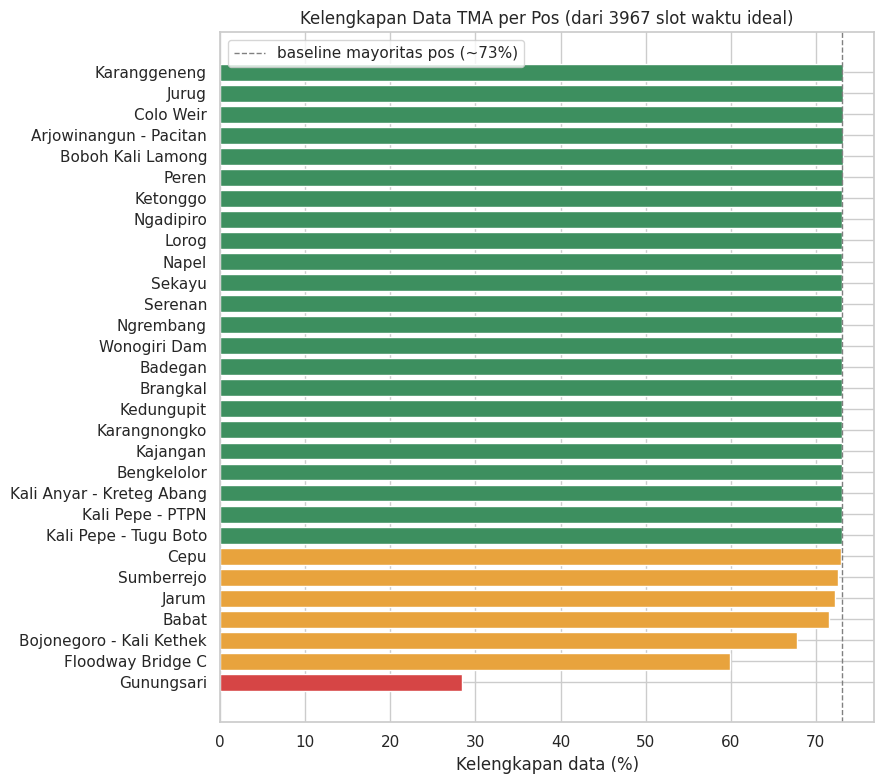

nama_pos
Gunungsari                  28.384169
Floodway Bridge C           59.919335
Bojonegoro - Kali Kethek    67.759012
Babat                       71.540207
Jarum                       72.195614
Sumberrejo                  72.548525
Cepu                        72.926645
Kali Pepe - Tugu Boto       73.103101
Name: datetime, dtype: float64

In [4]:
full_grid = pd.date_range(train.datetime.min(), train.datetime.max(), freq='6h')
n_full = len(full_grid)

completeness = (train.groupby('nama_pos')['datetime'].count() / n_full * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#d64545' if v < 50 else '#e8a33d' if v < 73 else '#3d8f5f' for v in completeness.values]
ax.barh(completeness.index, completeness.values, color=colors)
ax.axvline(73.1, color='gray', ls='--', lw=1, label='baseline mayoritas pos (~73%)')
ax.set_xlabel('Kelengkapan data (%)')
ax.set_title(f'Kelengkapan Data TMA per Pos (dari {n_full} slot waktu ideal)')
ax.legend()
plt.tight_layout()
plt.show()

completeness.head(8)

**Insight:** Mayoritas pos "cuma" punya kelengkapan ~73% ini kayaknya bukan random missing, tapi pola pengumpulan data yang emang bolong-bolong (misal ada rentang tanggal tertentu yang seluruh pos sama-sama nggak ada datanya). Tapi ada 2 pos yang jomplang banget: **Gunungsari** (~28%) dan **Floodway Bridge C** (~60%) dua pos ini butuh perlakuan khusus pas modeling (mungkin butuh imputasi lebih agresif, atau di-drop kalau kualitasnya kebangetan jelek).

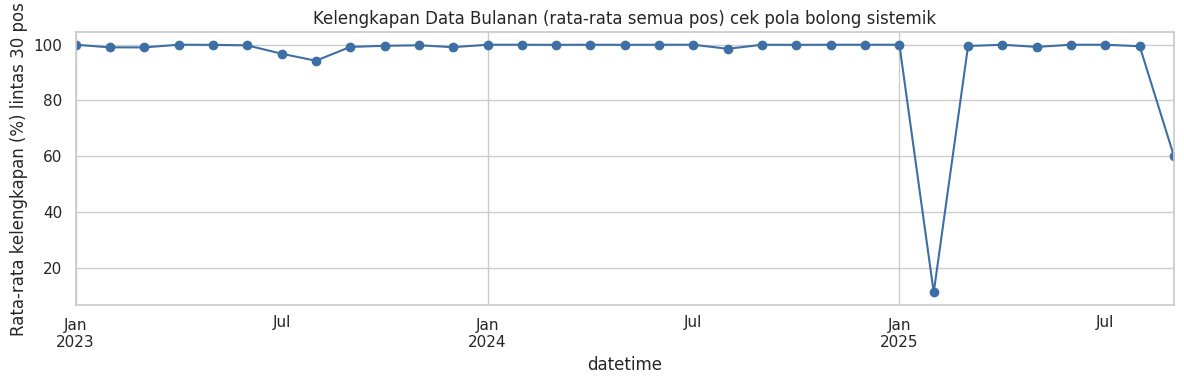

In [5]:
pivot_count = train.pivot_table(index=train.datetime.dt.to_period('M'), columns='nama_pos',
                                 values='tma_mdpl', aggfunc='count')
ideal_per_month = pivot_count.index.map(lambda p: p.days_in_month * 3)
monthly_pct = (pivot_count.mean(axis=1) / ideal_per_month * 100)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_pct.plot(ax=ax, marker='o', color='#3d6fa5')
ax.set_ylabel('Rata-rata kelengkapan (%) lintas 30 pos')
ax.set_title('Kelengkapan Data Bulanan (rata-rata semua pos) cek pola bolong sistemik')
plt.tight_layout()
plt.show()

## 3. Skala TMA Beda-beda Tiap Pos (Penting!)

### Tujuan
Cek `count`/`min`/`mean`/`max`/`std` TMA per pos, untuk konfirmasi seberapa jauh skalanya beda-beda antar pos ini nentuin banyak keputusan desain di Bagian 2 (baseline per-pos, evaluasi per-pos, dst).

### Metode
`groupby('nama_pos')['tma_mdpl'].agg(['count','min','mean','max','std'])`, diurut dari `mean` terkecil ke terbesar biar langsung kelihatan rentang skala dari pos "rendah" ke pos "tinggi".

### Kenapa Ini Penting
`tma_mdpl` itu "meter di atas permukaan laut", bukan tinggi air relatif dari dasar sungai. Jadi nilainya dipengaruhi elevasi lokasi pos itu sendiri pos di hulu pegunungan bisa punya baseline ratusan meter, pos di hilir dekat laut bisa mendekati nol. **Artinya model harus per-pos aware** (pakai `nama_pos` sebagai fitur/kategori, atau normalisasi per pos), bukan disamain semua.

### Cara Baca
Kolom `std` juga dipakai belakangan (poin #5) buat nentuin pos mana yang paling "stabil" vs "fluktuatif" perhatiin variasi std antar pos, bukan cuma variasi mean-nya.

In [6]:
stats = train.groupby('nama_pos')['tma_mdpl'].agg(['count', 'min', 'mean', 'max', 'std']).sort_values('mean')
stats.round(2)

,count,min,mean,max,std
nama_pos,,,,,
Arjowinangun - Pacitan,2903,0.35,1.12,4.85,0.49
Karanggeneng,2903,0.00,2.17,5.13,0.97
Floodway Bridge C,2377,2.04,3.87,47.00,1.38
Boboh Kali Lamong,2902,2.10,4.11,7.60,1.29
Babat,2838,4.41,6.31,9.66,0.77
Sumberrejo,2878,4.96,7.45,12.58,1.34
Bojonegoro - Kali Kethek,2688,0.00,9.06,225.13,5.72
Bengkelolor,2901,7.59,9.81,13.52,1.38
Gunungsari,1126,9.02,10.04,13.70,0.68


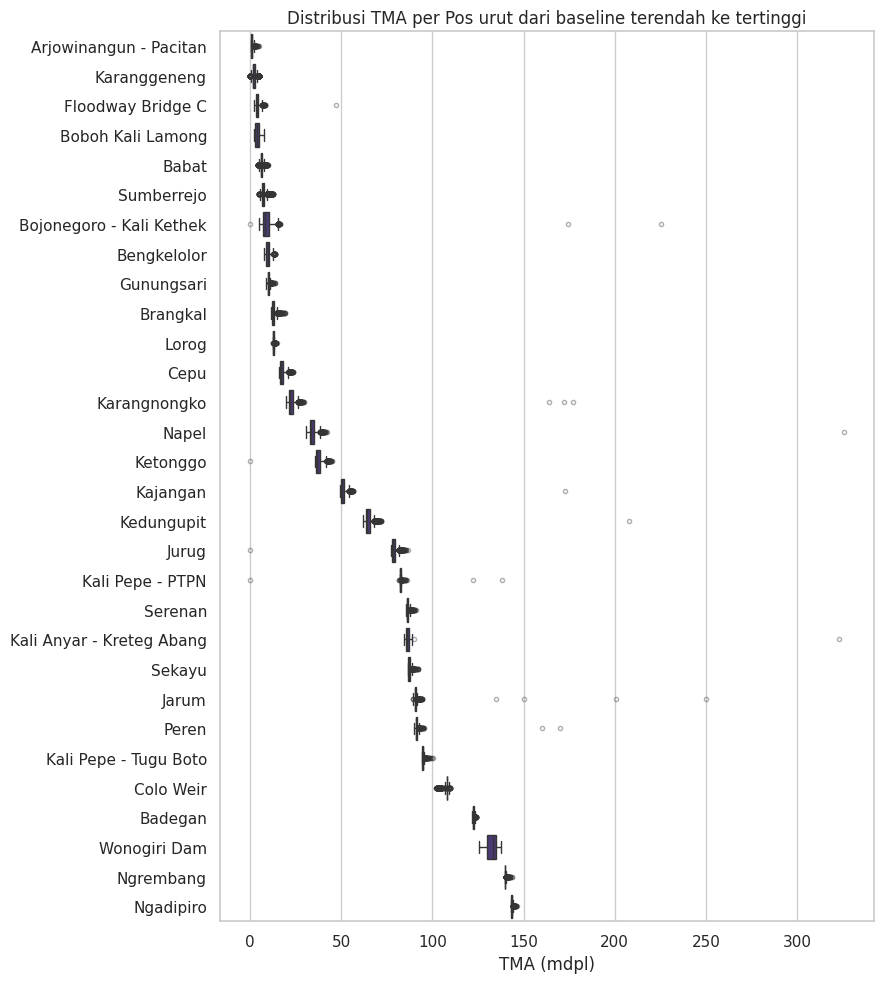

In [7]:
order = train.groupby('nama_pos')['tma_mdpl'].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 10))
sns.boxplot(data=train, y='nama_pos', x='tma_mdpl', order=order, ax=ax, showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_xlabel('TMA (mdpl)')
ax.set_ylabel('')
ax.set_title('Distribusi TMA per Pos urut dari baseline terendah ke tertinggi')
plt.tight_layout()
plt.show()

## 4. Deteksi Outlier Ekstrem per Pos

### Tujuan
Tandai baris yang nilainya jauh di luar IQR (per pos, biar adil buat pos berskala beda-beda) sebagai kandidat outlier, lalu hitung berapa banyak per pos.

### Metode
Batas outlier dihitung **per `nama_pos`** (bukan global) penting karena skala TMA beda jauh antar pos (poin #3), jadi threshold global bakal salah kaprah (nganggep pos berskala besar semua "outlier" padahal itu emang levelnya):
```
Q1, Q3 = kuartil 25% dan 75% per pos
IQR = Q3 - Q1
batas bawah = Q1 - 3*IQR
batas atas  = Q3 + 3*IQR
```
Faktor pengali `3` (bukan `1.5` standar) dipakai biar lebih longgar 1.5 terlalu agresif buat data time series yang emang punya variasi musiman/hidrologi wajar, bisa kebanyakan flag false positive.

### Kenapa Ini Penting
Beberapa pos (misalnya Kali Anyar - Kreteg Abang, Napel, Bojonegoro - Kali Kethek) punya nilai maksimum yang jauh di atas rata-ratanya. Ini bisa jadi (a) banjir beneran / lonjakan TMA asli, atau (b) noise sensor / salah catat dicek lebih lanjut di poin #18, dan dibersihin di Bagian 2 (Modeling) kalau terbukti sensor glitch.

### Cara Baca
`outlier_summary` nunjukin jumlah baris ter-flag per pos, diurut dari terbanyak. Pos paling atas (`top_pos`, dipakai lagi di poin #18) itu prioritas buat di-cross-check.

In [8]:
q1 = train.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.quantile(0.25))
q3 = train.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1
lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
train['is_outlier'] = (train['tma_mdpl'] < lo) | (train['tma_mdpl'] > hi)

outlier_summary = train.groupby('nama_pos')['is_outlier'].sum().sort_values(ascending=False)
outlier_summary[outlier_summary > 0]

nama_pos
Colo Weir                    212
Ngrembang                    160
Sumberrejo                   126
Babat                         99
Jarum                         55
Brangkal                      40
Lorog                         40
Ngadipiro                     36
Kali Pepe - Tugu Boto         31
Kedungupit                    28
Jurug                         28
Peren                         26
Sekayu                        26
Kali Pepe - PTPN              25
Serenan                       25
Gunungsari                    20
Arjowinangun - Pacitan        17
Badegan                        8
Karangnongko                   5
Bojonegoro - Kali Kethek       2
Napel                          2
Floodway Bridge C              1
Kali Anyar - Kreteg Abang      1
Ketonggo                       1
Kajangan                       1
Name: is_outlier, dtype: int64

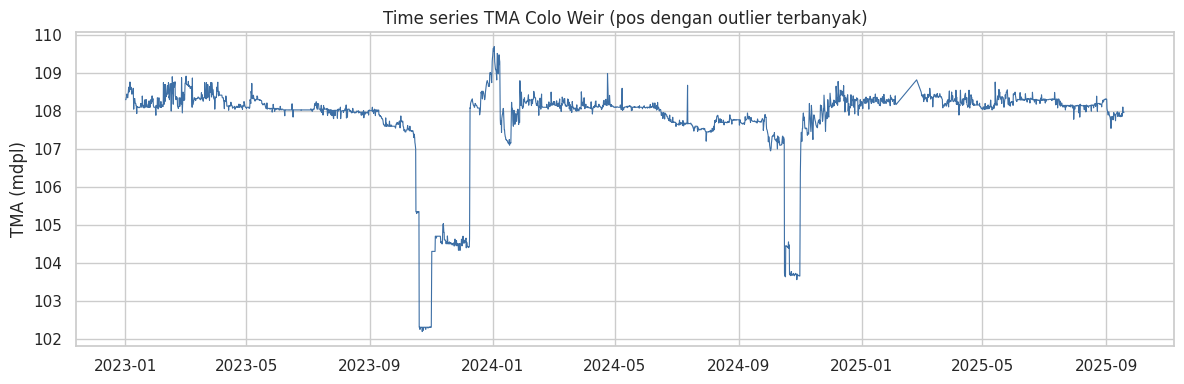

In [9]:
top_pos = outlier_summary.index[0]
sub = train[train.nama_pos == top_pos].sort_values('datetime')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sub.datetime, sub.tma_mdpl, lw=0.8, color='#3d6fa5')
ax.set_title(f'Time series TMA {top_pos} (pos dengan outlier terbanyak)')
ax.set_ylabel('TMA (mdpl)')
plt.tight_layout()
plt.show()

**Update (setelah dicek manual per-titik, lihat juga bagian Modeling section 1):** dugaan "banjir asli" ternyata KELIRU buat sebagian besar spike ini. Polanya bukan naik-turun bertahap selama beberapa hari (ciri banjir asli) tapi naik ratusan meter dalam SATU bacaan (6 jam) lalu balik PERSIS ke level semula di bacaan berikutnya. Itu ciri khas sensor glitch satu-titik, bukan hidrologi asli. Titik-titik ini sudah dibersihkan di awal Bagian Modeling (`clean_sensor_glitches`, MAD threshold k=12) sebelum baseline/fitur dihitung jadi EDA di bawah section ini (yang masih pakai `train` mentah) boleh dibaca sebagai catatan historis, bukan kondisi data yang dipakai model final.

## 5. Contoh Time Series Pos Stabil vs Pos Fluktuatif

### Tujuan
Bandingin satu pos yang datanya halus/stabil (std terkecil dari poin #3) sama satu pos yang paling fluktuatif (std terbesar), biar kebayang variasi karakter antar pos secara visual bukan cuma angka statistik.

### Metode
`stable_pos` dan `volatile_pos` diambil dari ranking `std` di tabel `stats` (poin #3). Kedua pos ini juga dipakai lagi di poin #12 (ACF) sebagai representative case buat pos berkarakter beda.

### Cara Baca
Dua panel time series ditumpuk (`sharex=True` biar rentang tanggalnya sama persis), warna hijau = pos stabil, merah = pos fluktuatif. Perhatiin bukan cuma amplitudo variasinya, tapi juga apa ada pola musiman yang kelihatan kasat mata di masing-masing.

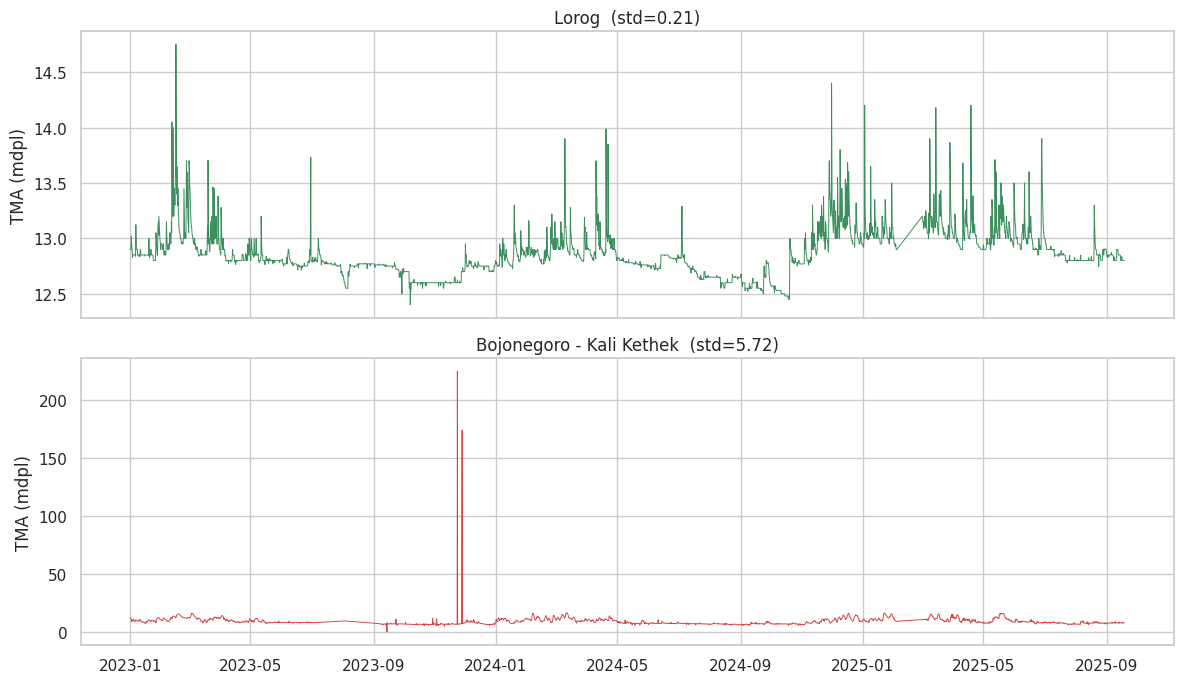

In [10]:
stable_pos = stats.sort_values('std').index[0]
volatile_pos = stats.sort_values('std', ascending=False).index[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, pos, color in zip(axes, [stable_pos, volatile_pos], ['#3d8f5f', '#d64545']):
    sub = train[train.nama_pos == pos].sort_values('datetime')
    ax.plot(sub.datetime, sub.tma_mdpl, lw=0.7, color=color)
    ax.set_title(f'{pos}  (std={stats.loc[pos, "std"]:.2f})')
    ax.set_ylabel('TMA (mdpl)')
plt.tight_layout()
plt.show()

## 6. Pola Musiman

### Tujuan
Cek apakah TMA ngikutin pola musim hujan/kemarau Indonesia secara konsisten lintas 30 pos.

### Metode
Indonesia punya musim hujan (umumnya Nov-Apr) dan musim kemarau (Mei-Okt). Karena skala TMA beda jauh antar pos (poin #3), nggak bisa langsung dirata-ratain mentah harus **standardisasi (z-score) per pos dulu**:
```
z = (tma_mdpl - mean_pos) / std_pos
```
Baru setelah itu di-rata-ratain lintas pos per bulan (`groupby('month')['z'].mean()`), biar pos berskala besar nggak mendominasi rata-rata.

### Cara Baca
Bar biru = bulan musim hujan (Nov-Apr), oranye = musim kemarau (Mei-Okt). Kalau pola musimannya jelas kebentuk (rata-rata z-score lebih tinggi/positif pas musim hujan, lebih rendah/negatif pas kemarau), itu sinyal kalau fitur kalender/musiman (dan baseline harmonic di Bagian 2) bakal berguna buat modeling.

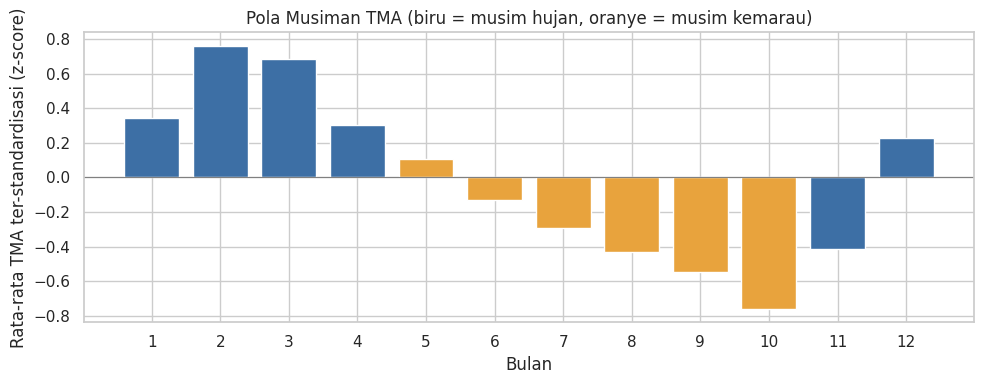

In [11]:
train['month'] = train.datetime.dt.month
train['z'] = train.groupby('nama_pos')['tma_mdpl'].transform(lambda x: (x - x.mean()) / x.std())

monthly_z = train.groupby('month')['z'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly_z.index, monthly_z.values,
              color=['#3d6fa5' if m in [11, 12, 1, 2, 3, 4] else '#e8a33d' for m in monthly_z.index])
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata TMA ter-standardisasi (z-score)')
ax.set_title('Pola Musiman TMA (biru = musim hujan, oranye = musim kemarau)')
plt.tight_layout()
plt.show()

**Insight:** Kalau pola musimannya jelas kebentuk (TMA lebih tinggi pas musim hujan Nov–Apr), berarti fitur kalender (bulan, hari-dalam-tahun sebagai sin/cos) bakal berguna sebagai fitur tambahan di luar curah hujan langsung.

## 7. Korelasi TMA dengan Fitur Eksogen

### Tujuan
Cek korelasi instan (di jam yang sama) antara TMA dan fitur cuaca/lingkungan, sebagai baseline sebelum nyoba versi lag/akumulasi di poin #11.

### Metode
1. `data_lingkungan.csv` datanya per jam sedangkan TMA cuma di jam 06/12/18. Kita filter env ke 3 jam itu (`env_match`) biar bisa di-join langsung versi simpel dulu; nanti pas modeling bisa dibikin fitur agregat kayak curah hujan kumulatif 6/24 jam sebelumnya (lihat poin #11 dan Bagian 2).
2. Join `train` + `env_match` di `datetime` + `nama_pos` (`how='inner'`), cek berapa baris yang berhasil ke-match.

### Fitur yang Dipakai
`rainfall_mm`, `humidity_pct`, `dew_point_c`, `cloud_cover_pct`, `temperature_c`, `wind_speed_kmh`, `rainfall_openmeteo_mm` (sumber alternatif curah hujan), `rainfall_max_24h_mm`, `solar_radiation_mj_m2`, 4 level `soil_moisture` (kedalaman 0-7cm, 7-28cm, 28-100cm, 100-255cm), `surface_pressure_hpa`, `pressure_msl_hpa`, `nino_34`.

### Cara Baca
Angka "baris ketemu setelah merge" dibandingin ke total baris `train` kalau jauh lebih kecil, artinya ada gap besar antara periode TMA dan periode data eksogen yang perlu diinvestigasi lebih lanjut.

In [12]:
env_cols = ['datetime', 'nama_pos', 'rainfall_mm', 'humidity_pct', 'dew_point_c',
            'cloud_cover_pct', 'temperature_c', 'wind_speed_kmh', 'rainfall_openmeteo_mm',
            'rainfall_max_24h_mm', 'solar_radiation_mj_m2', 'soil_moisture_0_7cm',
            'soil_moisture_7_28cm', 'soil_moisture_28_100cm', 'soil_moisture_100_255cm',
            'surface_pressure_hpa', 'pressure_msl_hpa', 'nino_34']

env = pd.read_csv(f'{BASE}/data_pendukung/data_lingkungan.csv', usecols=env_cols)
env['datetime'] = pd.to_datetime(env['datetime'])
env_match = env[env['datetime'].dt.hour.isin([6, 12, 18])]

merged = train.merge(env_match, on=['datetime', 'nama_pos'], how='inner')
print('Baris ketemu setelah merge:', merged.shape[0], '/', train.shape[0])

Baris ketemu setelah merge: 84396 / 84396


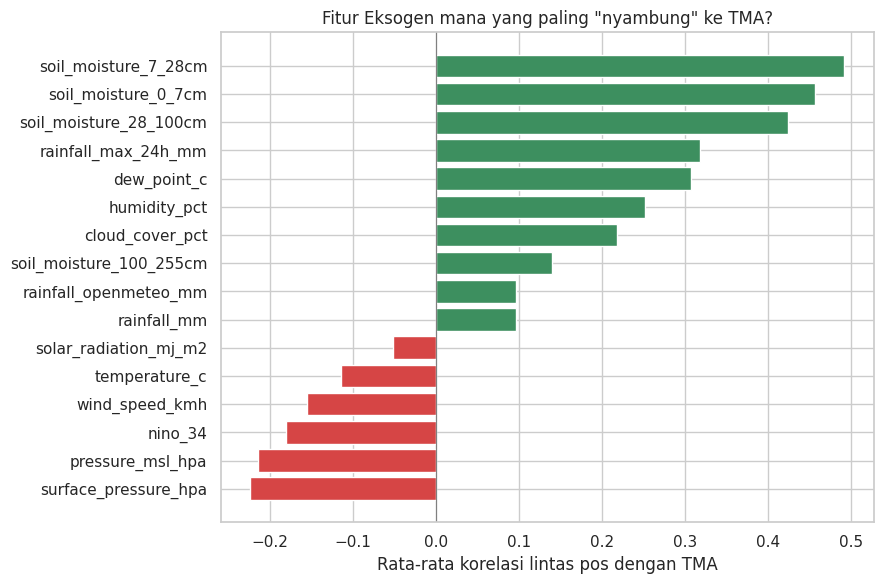

surface_pressure_hpa      -0.223308
pressure_msl_hpa          -0.214729
nino_34                   -0.180168
wind_speed_kmh            -0.155353
temperature_c             -0.114442
solar_radiation_mj_m2     -0.051294
rainfall_mm                0.097153
rainfall_openmeteo_mm      0.097153
soil_moisture_100_255cm    0.140329
cloud_cover_pct            0.217889
humidity_pct               0.252000
dew_point_c                0.308017
rainfall_max_24h_mm        0.317737
soil_moisture_28_100cm     0.424790
soil_moisture_0_7cm        0.457463
soil_moisture_7_28cm       0.492166
dtype: float64

In [13]:
feat_cols = [c for c in env_cols if c not in ['datetime', 'nama_pos']]

corrs = []
for pos, g in merged.groupby('nama_pos'):
    if g.shape[0] < 30:
        continue
    corrs.append(g[feat_cols + ['tma_mdpl']].corr()['tma_mdpl'].drop('tma_mdpl'))
corr_df = pd.DataFrame(corrs)
avg_corr = corr_df.mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d64545' if v < 0 else '#3d8f5f' for v in avg_corr.values]
ax.barh(avg_corr.index, avg_corr.values, color=colors)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Rata-rata korelasi lintas pos dengan TMA')
ax.set_title('Fitur Eksogen mana yang paling "nyambung" ke TMA?')
plt.tight_layout()
plt.show()

avg_corr

**Insight:** Fitur soil moisture & curah hujan biasanya paling relevan buat hidrologi (tanah yang udah jenuh air bikin limpasan ke sungai lebih cepat naikin TMA). Kalau hasil di atas nunjukin soil_moisture / rainfall punya korelasi positif paling kuat, itu konsisten sama teori cocok jadi fitur prioritas. Tekanan udara & suhu biasanya korelasinya lebih lemah/tidak langsung, tapi masih bisa berguna sebagai proxy kondisi atmosfer.

## 8. Sebaran Lokasi 30 Pos

### Tujuan
Plot cepat posisi pos berdasarkan lat/lon, diwarnai sama rata-rata TMA-nya buat ngerasain sebaran hulu-hilir secara kasar sebelum masuk analisis proxy hulu-hilir yang lebih formal di poin #14.

### Metode
Merge `koor` (lat/lon) dengan `stats` (rata-rata TMA per pos dari poin #3), scatter plot dengan colormap `viridis` berdasarkan rata-rata TMA, tiap titik dikasih label nama pos.

### Cara Baca
Warna lebih terang/kuning = TMA rata-rata lebih tinggi (biasanya pos hulu/elevasi tinggi), warna gelap/ungu = TMA rata-rata lebih rendah (biasanya pos hilir dekat laut). Pola spasial ini konsisten sama penjelasan di poin #3 soal skala TMA yang dipengaruhi elevasi.

### Catatan
Bukan peta hidrologi presisi (belum pakai shapefile HydroRIVERS itu ukurannya ~200MB, terlalu berat buat EDA cepat), cuma sebaran koordinat mentah. Proxy hulu-hilir yang lebih formal (kombinasi jarak + korelasi TMA) ada di poin #14.

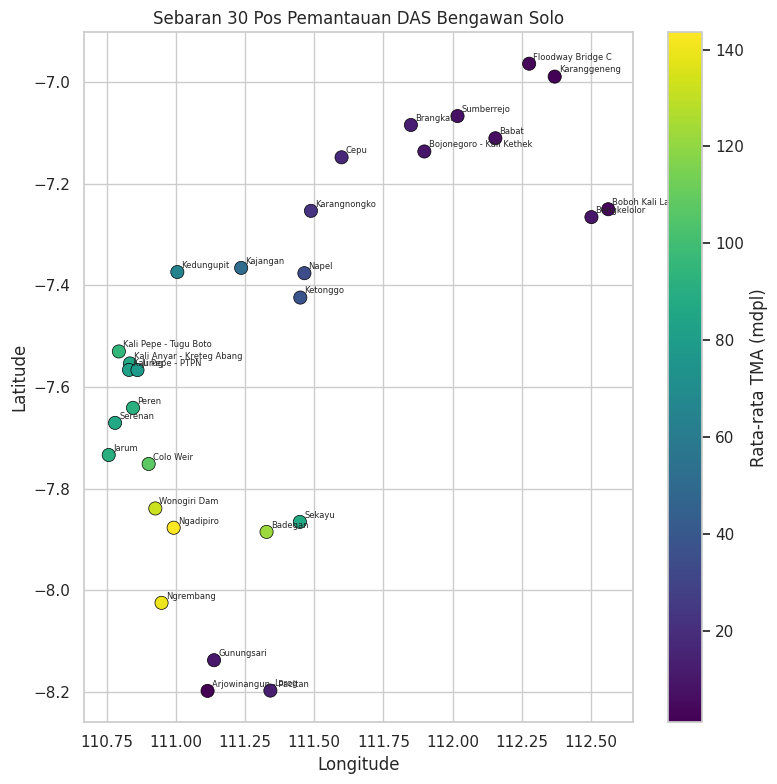

In [14]:
koor_stats = koor.merge(stats.reset_index(), on='nama_pos', how='left')

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(koor_stats.longitude, koor_stats.latitude, c=koor_stats['mean'],
                 cmap='viridis', s=90, edgecolor='k', linewidth=0.5)
for _, r in koor_stats.iterrows():
    ax.annotate(r['nama_pos'], (r['longitude'], r['latitude']), fontsize=6,
                xytext=(3, 3), textcoords='offset points')
plt.colorbar(sc, label='Rata-rata TMA (mdpl)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Sebaran 30 Pos Pemantauan DAS Bengawan Solo')
plt.tight_layout()
plt.show()

**Insight:** Pos dengan baseline TMA tinggi (warna cerah) cenderung ngumpul di area tertentu (kemungkinan area hulu/dataran tinggi), sementara yang rendah di area lain (dekat hilir/laut). Ini nunjukin **lokasi geografis sendiri berpotensi jadi fitur berguna** (lat/lon, atau jarak ke laut/hulu), selain identitas kategorikal `nama_pos`. Kalau mau lebih presisi, `HydroRIVERS_v10_au_shp` (shapefile jaringan sungai yang disediakan panitia) bisa dipakai buat hitung urutan hulu-hilir/upstream-downstream antar pos.

## 9. Indeks Iklim Global (Niño 3.4 & MJO)

### Tujuan
Lihat pola `nino_34` sepanjang periode data (termasuk periode test), dan cek relevansinya ke curah hujan regional.

### Kenapa Fitur Ini Beda
`nino_34` dan fitur MJO (rmm1, rmm2, mjo_phase, mjo_amplitude) itu indeks iklim global nilainya **sama untuk semua pos** di tanggal yang sama (bukan spesifik per pos kayak curah hujan lokal). Ini nangkep pola iklim skala besar (El Niño/La Niña, gelombang Madden-Julian) yang mempengaruhi curah hujan regional dalam skala mingguan-bulanan beda sama fitur cuaca lokal (poin #7) yang variasinya harian dan spesifik per lokasi.

### Metode
`env.drop_duplicates(subset='datetime')` karena nilainya sama di semua pos, cukup ambil 1 baris per datetime. Resample ke harian (`.resample('D').mean()`) biar plotnya nggak terlalu ramai dari data per-jam.

### Cara Baca
Area merah = fase El Niño (`nino_34 > 0`, cenderung kering), hijau = La Niña (`nino_34 <= 0`, cenderung basah), area abu-abu = periode test (Sep 2025 - Mei 2026). Ini nunjukin apa periode test bakal didominasi fase El Niño atau La Niña relevan buat interpretasi hasil prediksi nantinya, dan konfirmasi kalau panitia emang udah nyediain nilai indeks ini sampai ke ujung periode test (nggak perlu forecast index-nya sendiri).

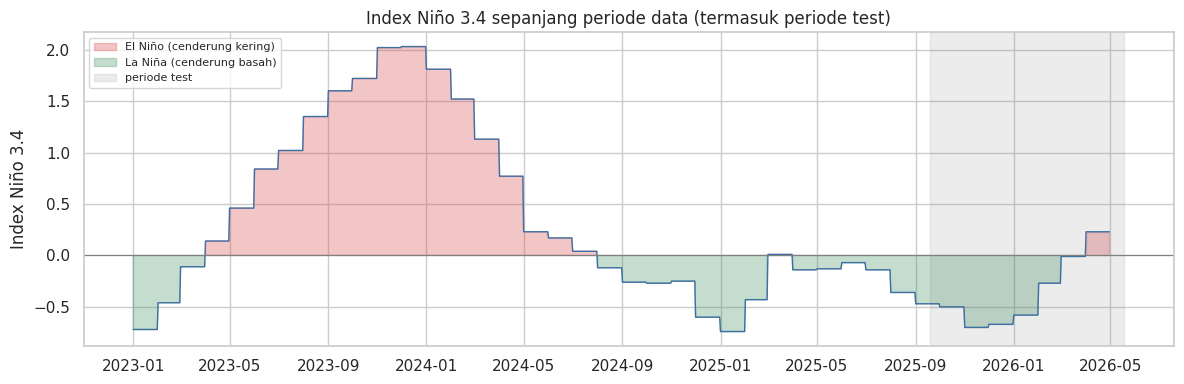

In [15]:
env_global = env.drop_duplicates(subset='datetime')[['datetime', 'nino_34']].sort_values('datetime')
env_global_daily = env_global.set_index('datetime').resample('D').mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(env_global_daily.index, env_global_daily.nino_34, color='#3d6fa5', lw=1)
ax.axhline(0, color='gray', lw=0.8)
ax.fill_between(env_global_daily.index, 0, env_global_daily.nino_34,
                 where=(env_global_daily.nino_34 > 0), color='#d64545', alpha=0.3, label='El Niño (cenderung kering)')
ax.fill_between(env_global_daily.index, 0, env_global_daily.nino_34,
                 where=(env_global_daily.nino_34 <= 0), color='#3d8f5f', alpha=0.3, label='La Niña (cenderung basah)')
ax.axvspan(train.datetime.max(), test.datetime.max(), color='gray', alpha=0.15, label='periode test')
ax.set_ylabel('Index Niño 3.4')
ax.set_title('Index Niño 3.4 sepanjang periode data (termasuk periode test)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Insight:** Karena panitia udah nyediain nilai `nino_34`/MJO sampai ke periode test (Mei 2026), fitur ini **valid dipakai langsung tanpa perlu forecast sendiri** beda sama TMA yang harus diprediksi. Ini jadi salah satu "jangkar" sinyal iklim jangka panjang yang paling reliable buat model forecasting jarak jauh.

## 10. Skala TMA vs Keadilan Metric RMSE

### Tujuan
Karena skala TMA beda jauh antar pos (poin #3), cek langsung dampaknya ke metric evaluasi kompetisi: pos mana yang bakal paling "dominan" nyumbang ke total squared error kalau semua pos digabung jadi satu RMSE (kayak cara panitia nge-score submission).

### Metode
1. Baseline paling naif: tebak rata-rata `tma_mdpl` per pos (`naive_pred`).
2. Hitung squared error per baris (`sq_err_naive`), lalu:
   - `rmse_naive_baseline`: RMSE per pos (akar rata-rata squared error di pos itu).
   - `kontribusi_ke_total_SE_%`: seberapa besar porsi pos itu ke **total** squared error gabungan (bukan RMSE per pos ini yang beneran nentuin skor RMSE gabungan kompetisi).

### Cara Baca
Garis putus-putus di `100/30% ≈ 3.33%` = kontribusi "adil" kalau merata ke 30 pos. Pos yang jauh di atas garis itu artinya skala TMA-nya besar (RMSE per posnya besar) dan bakal mendominasi RMSE gabungan model harus bagus khususnya di pos-pos itu, bukan cuma bagus rata-rata. Ini insight yang langsung dipakai di Bagian 2 buat mikirin evaluasi per-pos, bukan cuma RMSE gabungan doang.

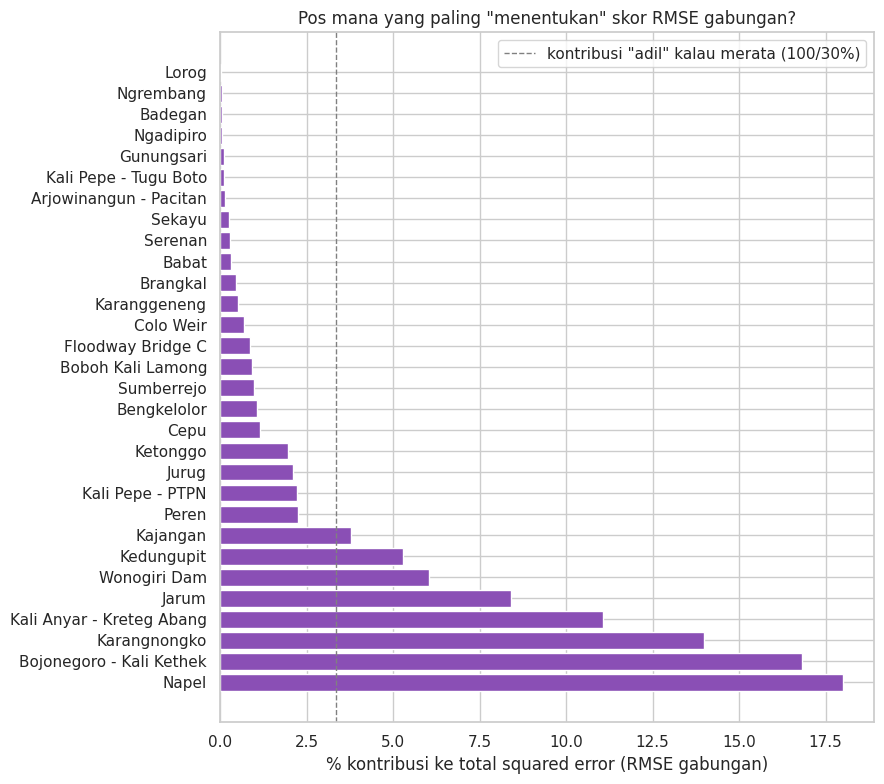

,rmse_naive_baseline,kontribusi_ke_total_SE_%
nama_pos,,
Napel,5.69,18.00
Bojonegoro - Kali Kethek,5.72,16.83
Karangnongko,5.02,14.00
Kali Anyar - Kreteg Abang,4.46,11.07
Jarum,3.92,8.42
Wonogiri Dam,3.30,6.05
Kedungupit,3.08,5.27
Kajangan,2.61,3.78
Peren,2.02,2.26


In [16]:
naive_pred = train.groupby('nama_pos')['tma_mdpl'].transform('mean')
train['sq_err_naive'] = (train['tma_mdpl'] - naive_pred) ** 2

rmse_naive = train.groupby('nama_pos')['sq_err_naive'].mean() ** 0.5
kontribusi = train.groupby('nama_pos')['sq_err_naive'].sum() / train['sq_err_naive'].sum() * 100

fair_df = pd.DataFrame({'rmse_naive_baseline': rmse_naive, 'kontribusi_ke_total_SE_%': kontribusi}).sort_values('kontribusi_ke_total_SE_%', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(fair_df.index, fair_df['kontribusi_ke_total_SE_%'], color='#8a4fb5')
ax.axvline(100/30, color='gray', ls='--', lw=1, label='kontribusi "adil" kalau merata (100/30%)')
ax.set_xlabel('% kontribusi ke total squared error (RMSE gabungan)')
ax.set_title('Pos mana yang paling "menentukan" skor RMSE gabungan?')
ax.legend()
plt.tight_layout()
plt.show()

fair_df.round(2).head(10)

## 11. Korelasi dengan Lag Curah Hujan & Soil Moisture "Nunda" Efeknya ke TMA

### Tujuan
Cek apakah fitur akumulasi (rolling 24 jam & 72 jam) curah hujan/soil moisture berkorelasi lebih kuat ke TMA dibanding versi instan (poin #7) kalau iya, itu fitur yang worth dipakai di modeling.

### Kenapa Perlu Dicek
Air itu nggak langsung naik pas hujan turun butuh waktu meresap/mengalir (limpasan permukaan + infiltrasi tanah). Korelasi instan (poin #7) mungkin under-estimate hubungan sebenarnya, karena efek hujan ke TMA baru kerasa beberapa jam sampai beberapa hari kemudian.

### Metode
Per pos, hitung 3 fitur akumulasi pakai rolling window berbasis waktu (bukan berbasis jumlah baris, biar tahan terhadap gap missing):
| Fitur | Rolling Window | Agregasi |
|---|---|---|
| `rain_24h` | 24 jam | Sum (total curah hujan) |
| `rain_72h` | 72 jam | Sum (total curah hujan) |
| `soil_24h` | 24 jam | Mean (rata-rata kelembapan tanah) |

Lalu di-merge ke `train` sama kayak poin #7, buat dibandingin korelasinya.

In [17]:
def add_lag_features(g):
    g = g.set_index('datetime').sort_index()
    g['rain_24h'] = g['rainfall_mm'].rolling('24h', min_periods=1).sum()
    g['rain_72h'] = g['rainfall_mm'].rolling('72h', min_periods=1).sum()
    g['soil_24h'] = g['soil_moisture_0_7cm'].rolling('24h', min_periods=1).mean()
    return g.reset_index()

env_lag_parts = []
for pos, g in env.groupby('nama_pos'):
    part = add_lag_features(g)
    part['nama_pos'] = pos
    env_lag_parts.append(part)
env_lag = pd.concat(env_lag_parts, ignore_index=True)
env_lag_match = env_lag[env_lag['datetime'].dt.hour.isin([6, 12, 18])]

merged_lag = train.merge(env_lag_match[['datetime', 'nama_pos', 'rain_24h', 'rain_72h', 'soil_24h']],
                          on=['datetime', 'nama_pos'], how='inner')

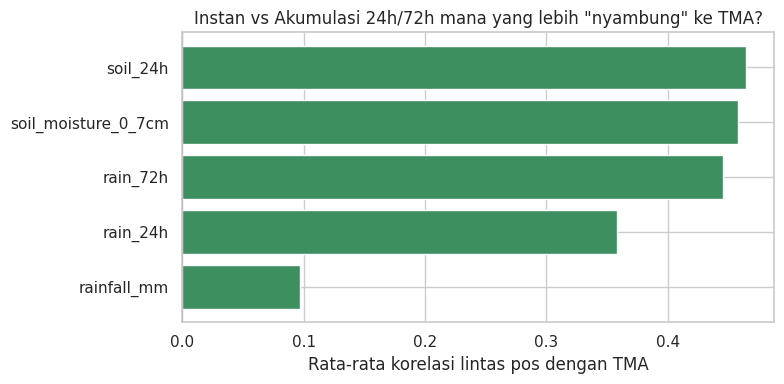

rainfall_mm            0.097153
rain_24h               0.358243
rain_72h               0.445141
soil_moisture_0_7cm    0.457463
soil_24h               0.464242
dtype: float64

In [18]:
lag_feat_cols = ['rainfall_mm', 'rain_24h', 'rain_72h', 'soil_moisture_0_7cm', 'soil_24h']
merged_lag_full = merged_lag.merge(env_match[['datetime', 'nama_pos', 'rainfall_mm', 'soil_moisture_0_7cm']],
                                    on=['datetime', 'nama_pos'], how='left')

lag_corrs = []
for pos, g in merged_lag_full.groupby('nama_pos'):
    if g.shape[0] < 30:
        continue
    lag_corrs.append(g[lag_feat_cols + ['tma_mdpl']].corr()['tma_mdpl'].drop('tma_mdpl'))
lag_corr_df = pd.DataFrame(lag_corrs)
avg_lag_corr = lag_corr_df.mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d64545' if v < 0 else '#3d8f5f' for v in avg_lag_corr.values]
ax.barh(avg_lag_corr.index, avg_lag_corr.values, color=colors)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Rata-rata korelasi lintas pos dengan TMA')
ax.set_title('Instan vs Akumulasi 24h/72h mana yang lebih "nyambung" ke TMA?')
plt.tight_layout()
plt.show()

avg_lag_corr

## 12. Autokorelasi TMA (ACF) Seberapa Jauh Lag Masih Berguna?

### Tujuan
Ngecek sampai lag berapa (dalam kelipatan 6 jam) nilai TMA masih "nyambung" ke nilai sekarang bantu mutusin lag feature mana yang worth dipakai (kalau ACF-nya udah deket 0 di lag tertentu, lag lebih jauh dari itu kemungkinan besar nggak nambah info).

### Metode
ACF dihitung manual (`acf_manual`, bukan pakai `statsmodels`) buat 2 pos representative dari poin #5 (`stable_pos` dan `volatile_pos`), sampai lag 40 (=240 jam=10 hari). Batas signifikansi 95% dihitung pakai rumus standar `1.96/sqrt(n)`.

### Cara Baca
Area abu-abu = batas signifikansi 95%. Batang yang keluar dari area itu artinya lag tersebut masih berkorelasi signifikan sama nilai sekarang. Bandingin pola ACF `stable_pos` vs `volatile_pos` biasanya pos stabil punya ACF yang meluruh lebih pelan (persistensi tinggi, lag jauh masih berguna) dibanding pos volatile.

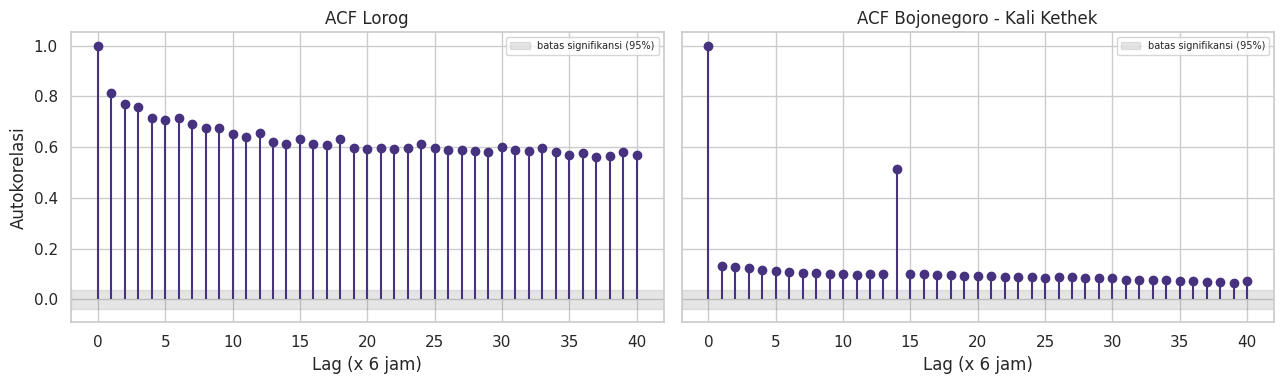

In [19]:
def acf_manual(series, nlags):
    x = series.values - series.values.mean()
    n = len(x)
    var = np.sum(x ** 2)
    return np.array([1.0] + [np.sum(x[:-lag] * x[lag:]) / var for lag in range(1, nlags + 1)])

nlags = 40
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, pos in zip(axes, [stable_pos, volatile_pos]):
    s = train[train.nama_pos == pos].sort_values('datetime')['tma_mdpl']
    vals = acf_manual(s, nlags)
    ci = 1.96 / np.sqrt(len(s))
    ax.stem(range(nlags + 1), vals, basefmt=' ')
    ax.axhspan(-ci, ci, color='gray', alpha=0.2, label='batas signifikansi (95%)')
    ax.set_title(f'ACF {pos}')
    ax.set_xlabel('Lag (x 6 jam)')
    ax.legend(fontsize=7)
axes[0].set_ylabel('Autokorelasi')
plt.tight_layout()
plt.show()

## 13. Cek Pergeseran Distribusi Fitur Eksogen: Train vs Test

### Tujuan
Bandingin distribusi (mean/min/max) beberapa fitur eksogen kunci antara periode train dan periode test, buat ngecek risiko ekstrapolasi.

### Kenapa Ini Penting
Model tree-based (LGBM/XGBoost) rawan jelek kalau nilai fitur di test jauh di luar range yang pernah dilihat pas training (ekstrapolasi) tree cuma bisa "mengulang" leaf value yang udah dipelajari dari data train, nggak bisa ekstrapolasi linear kayak model regresi. Jadi kalau `min_test` atau `max_test` jauh di luar rentang `min_train`/`max_train`, itu sinyal bahaya.

### Metode
Split `env` berdasarkan `train.datetime.max()` sebagai batas, bandingin `mean`/`min`/`max` dari 4 fitur kunci (`nino_34`, `rainfall_mm`, `soil_moisture_0_7cm`, `temperature_c`) di kedua periode.

### Cara Baca
Fokus ke kolom `min_test`/`max_test` dibanding `min_train`/`max_train` kalau ada yang jauh di luar rentang train, itu fitur yang perlu diwaspadai (Bagian 2 bisa pertimbangkan clipping/capping fitur tsb ke rentang train, atau treatment khusus).

In [20]:
batas = train.datetime.max()
env_train_period = env[env['datetime'] <= batas]
env_test_period = env[env['datetime'] > batas]

compare_cols = ['nino_34', 'rainfall_mm', 'soil_moisture_0_7cm', 'temperature_c']
shift_summary = pd.DataFrame({
    'mean_train': env_train_period[compare_cols].mean(),
    'mean_test': env_test_period[compare_cols].mean(),
    'min_train': env_train_period[compare_cols].min(),
    'min_test': env_test_period[compare_cols].min(),
    'max_train': env_train_period[compare_cols].max(),
    'max_test': env_test_period[compare_cols].max(),
}).round(3)
shift_summary

,mean_train,mean_test,min_train,min_test,max_train,max_test
nino_34,0.363,-0.366,-0.740,-0.700,2.03,0.230
rainfall_mm,0.256,0.367,0.000,0.000,34.60,40.500
soil_moisture_0_7cm,0.347,0.402,0.108,0.089,0.52,0.541
temperature_c,26.688,26.355,17.500,20.300,38.80,37.000


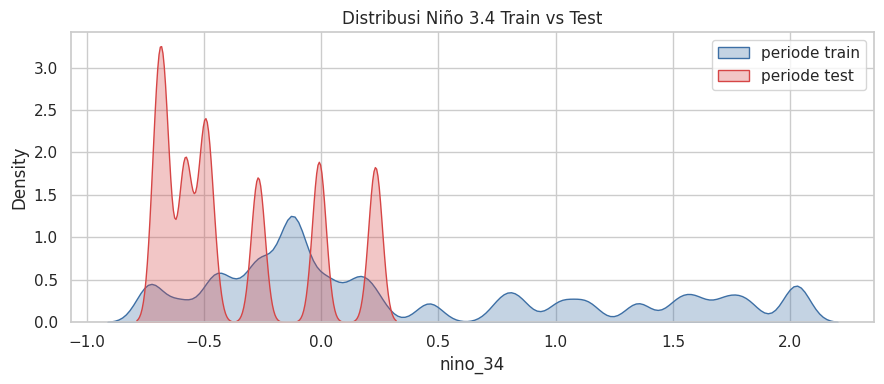

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(env_train_period['nino_34'], ax=ax, label='periode train', fill=True, alpha=0.3, color='#3d6fa5')
sns.kdeplot(env_test_period['nino_34'], ax=ax, label='periode test', fill=True, alpha=0.3, color='#d64545')
ax.set_title('Distribusi Niño 3.4 Train vs Test')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Proxy Hubungan Hulu-Hilir Antar Pos

### Tujuan
Cari proxy ringan buat hubungan hulu-hilir antar pos, sebagai dasar fitur "upstream" yang dipakai di Stage B (Bagian 2: Modeling).

### Metode
1. Hitung matriks korelasi TMA antar semua pasangan pos (`wide.corr()`, dari tabel pivot datetime x nama_pos).
2. Hitung jarak geografis (haversine, dalam km) antar tiap pasangan pos dari koordinat lat/lon.
3. Gabungin jadi satu tabel: `pos_a`, `pos_b`, `jarak_km`, `korelasi`.

### Kenapa Proxy Ini, Bukan Shapefile Langsung
Shapefile `HydroRIVERS` yang disediakan panitia ukurannya besar (~200MB), jadi buat EDA cepat kita pakai proxy yang lebih ringan: korelasi TMA antar pasangan pos, dihubungkan sama jarak geografis. Pos yang searah aliran sungai biasanya punya korelasi TMA yang lebih tinggi walau jaraknya lumayan jauh, dibanding pos yang jauh tapi beda DAS/cabang karena mereka "berbagi" air yang sama.

### Cara Baca
Scatter plot jarak vs korelasi: cari pasangan pos yang korelasinya tinggi meski jaraknya jauh (itu kandidat kuat hubungan hulu-hilir searah aliran) vs pasangan yang jaraknya deket tapi korelasinya rendah (kemungkinan beda cabang/DAS meski geografis berdekatan). `pair_df.sort_values('korelasi', ascending=False).head(10)` nunjukin 10 pasangan pos paling berkorelasi kandidat kuat buat fitur upstream di Bagian 2.

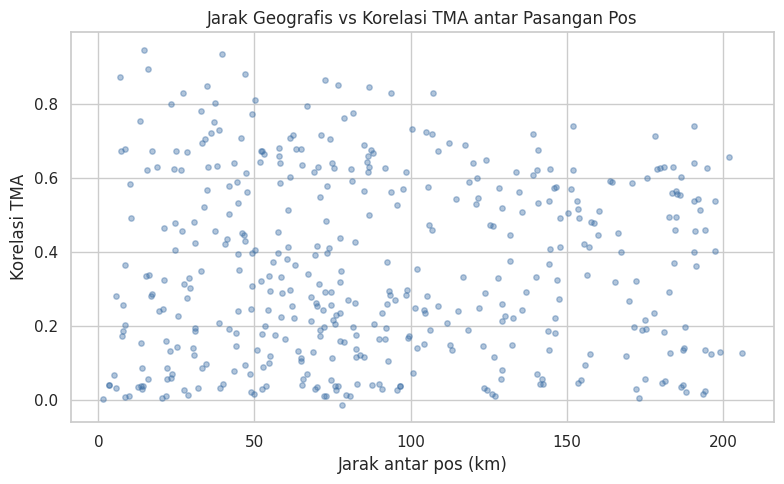

,pos_a,pos_b,jarak_km,korelasi
296,Jurug,Serenan,14.591603,0.946045
367,Karanggeneng,Sumberrejo,39.696323,0.936407
55,Babat,Sumberrejo,15.854607,0.894658
202,Cepu,Sumberrejo,47.114744,0.880309
84,Bengkelolor,Boboh Kali Lamong,6.913722,0.873942
295,Jurug,Sekayu,72.689837,0.864319
429,Sekayu,Serenan,76.704252,0.851211
194,Cepu,Ketonggo,34.798652,0.849398
191,Cepu,Karanggeneng,86.803952,0.845105
201,Cepu,Serenan,107.327576,0.831000


In [22]:
from math import radians, sin, cos, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

wide = train.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl')
corr_matrix = wide.corr()

koor_idx = koor.set_index('nama_pos')
pairs = []
names = corr_matrix.columns.tolist()
for i, a in enumerate(names):
    for b in names[i+1:]:
        if a in koor_idx.index and b in koor_idx.index:
            d = haversine(koor_idx.loc[a, 'latitude'], koor_idx.loc[a, 'longitude'],
                          koor_idx.loc[b, 'latitude'], koor_idx.loc[b, 'longitude'])
            pairs.append((a, b, d, corr_matrix.loc[a, b]))

pair_df = pd.DataFrame(pairs, columns=['pos_a', 'pos_b', 'jarak_km', 'korelasi']).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pair_df.jarak_km, pair_df.korelasi, alpha=0.4, s=15, color='#3d6fa5')
ax.set_xlabel('Jarak antar pos (km)')
ax.set_ylabel('Korelasi TMA')
ax.set_title('Jarak Geografis vs Korelasi TMA antar Pasangan Pos')
plt.tight_layout()
plt.show()

pair_df.sort_values('korelasi', ascending=False).head(10)

## 15. Pola Bolongnya Data Sistemik atau Acak?

### Tujuan
Cek langsung di slot waktu mana aja hampir semua pos sama-sama nggak ada datanya (bolong bareng = sistemik) vs bolong random per pos.

### Kenapa Ini Beda dari Poin #2
Poin #2 cuma ngasih persentase kelengkapan per pos (agregat sepanjang waktu). Di sini kita breakdown per slot waktu individual, biar ketauan APAKAH bolongnya konsentrasi di rentang tanggal tertentu (sinyal masalah sistemik, misal alat mati bareng/listrik padam serentak) atau tersebar acak antar pos dan waktu.

### Metode
Hitung jumlah pos yang punya data di tiap slot waktu (`count_per_time`), resample ke harian buat plot yang lebih smooth. `bad_slots` = slot waktu yang cuma dilaporkan oleh <=3 dari 30 pos (indikasi kuat masalah sistemik, bukan kebetulan beberapa pos random kosong barengan).

### Cara Baca
Kalau plot-nya nunjukin penurunan tajam yang bertahan lama (bukan spike sekejap), atau breakdown bulanan `bad_slots` nunjukin konsentrasi di bulan/rentang tertentu, itu konfirmasi pola sistemik bukan missing acak yang bisa diimputasi dengan aman.

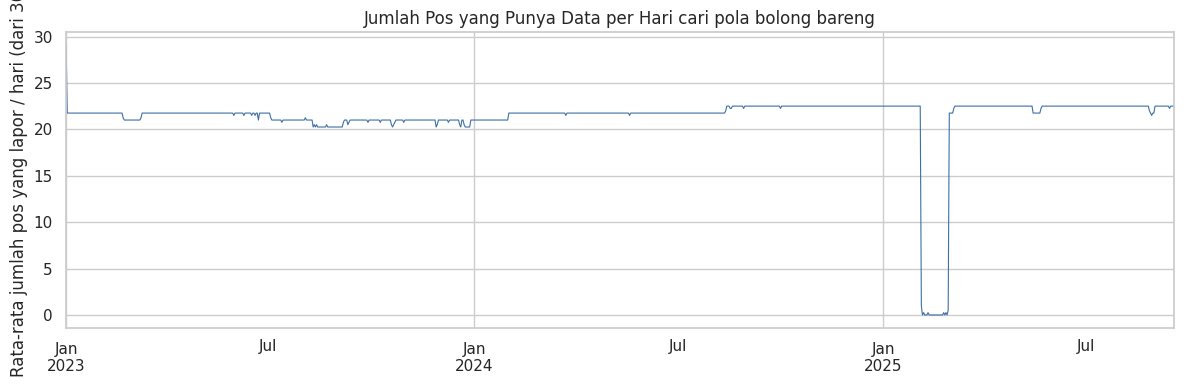

1066 dari 3967 slot waktu (26.9%) cuma dilaporkan <=3 dari 30 pos


2024-07     31
2024-08     31
2024-09     30
2024-10     31
2024-11     30
2024-12     31
2025-01     31
2025-02    103
2025-03     31
2025-04     30
2025-05     31
2025-06     30
2025-07     31
2025-08     31
2025-09     18
Freq: M, Name: tma_mdpl, dtype: int64

In [23]:
count_per_time = train.groupby('datetime')['tma_mdpl'].count().reindex(full_grid, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
count_per_time.resample('D').mean().plot(ax=ax, color='#3d6fa5', lw=0.8)
ax.set_ylabel('Rata-rata jumlah pos yang lapor / hari (dari 30)')
ax.set_title('Jumlah Pos yang Punya Data per Hari cari pola bolong bareng')
plt.tight_layout()
plt.show()

bad_slots = count_per_time[count_per_time <= 3]
print(f'{len(bad_slots)} dari {len(count_per_time)} slot waktu ({len(bad_slots)/len(count_per_time)*100:.1f}%) cuma dilaporkan <=3 dari 30 pos')
bad_slots.groupby(bad_slots.index.to_period('M')).count().tail(15)

## 16. Missing Value di `data_lingkungan.csv` (termasuk Periode Test)

### Tujuan
Cek persentase missing value di fitur eksogen kunci, dipisah antara periode train dan periode test.

### Kenapa Ini Serius
Fitur eksogen yang bolong di periode **test** itu masalah serius soalnya nggak ada cara "nunggu data aslinya update" kayak biasa, prediksinya harus jalan pakai apa yang ada (butuh strategi imputasi/fallback yang udah disiapkan dari awal, bukan dadakan). Beda sama missing di train yang masih bisa diimputasi/didrop tanpa mempengaruhi submission.

### Metode
Hitung persentase NaN per kolom (selain `datetime`/`nama_pos`), dipisah `env_train_period` vs `env_test_period` (pembagian sama kayak poin #13). Cuma kolom yang punya missing value (>0%) yang ditampilkan.

### Cara Baca
Kalau outputnya "Nggak ada missing value" aman, nggak perlu strategi imputasi eksogen. Kalau ada, prioritaskan kolom dengan `pct_NaN_periode_test` tinggi (itu yang paling kritis, karena nggak ada ground truth buat isi ulang).

In [24]:
na_compare = pd.DataFrame({
    'pct_NaN_periode_train': env_train_period.drop(columns=['datetime', 'nama_pos']).isna().mean() * 100,
    'pct_NaN_periode_test': env_test_period.drop(columns=['datetime', 'nama_pos']).isna().mean() * 100,
}).round(2)

if na_compare.sum(axis=1).sum() > 0:
    display(na_compare[na_compare.sum(axis=1) > 0])
else:
    print('Nggak ada missing value di kolom-kolom yang dicek — aman.')

,pct_NaN_periode_train,pct_NaN_periode_test
soil_moisture_0_7cm,0.0,0.41
soil_moisture_7_28cm,0.0,0.41
soil_moisture_28_100cm,0.0,0.41
soil_moisture_100_255cm,0.0,0.41
surface_pressure_hpa,0.0,0.41
pressure_msl_hpa,0.0,0.41
nino_34,0.0,7.43


## 17. Cek Duplicate Timestamp

### Tujuan
Sanity check simpel: pastiin nggak ada baris duplikat (`datetime` + `nama_pos` yang sama muncul lebih dari sekali), soalnya itu bisa bikin data leakage atau salah agregasi pas join.

### Metode
`duplicated(subset=['datetime','nama_pos'])` di `train` dan `env` (kolom yang dipakai), hitung berapa baris yang ke-flag duplikat.

### Cara Baca
Idealnya kedua angka = 0. Kalau nggak, perlu investigasi lebih lanjut baris duplikat pas di-join bisa bikin baris di `merged` lebih banyak dari yang seharusnya (fan-out), yang bisa mengacaukan agregasi/rata-rata di analisis-analisis sebelumnya.

In [25]:
dup_train = train.duplicated(subset=['datetime', 'nama_pos']).sum()
dup_env = env.duplicated(subset=['datetime', 'nama_pos']).sum()
print('Baris duplikat di train:', dup_train)
print('Baris duplikat di data_lingkungan (kolom yang dipakai):', dup_env)

Baris duplikat di train: 0
Baris duplikat di data_lingkungan (kolom yang dipakai): 0


## 18. Cross-check: Spike TMA Beneran Gara-gara Hujan?

### Tujuan
Balik ke pos dengan outlier terbanyak (`top_pos`, dari poin #4) tempelin curah hujan di tanggal yang sama, buat mastiin spike-nya emang dipicu hujan (bukan sekadar noise sensor).

### Metode
Ambil semua baris outlier di `top_pos`, merge sama `rainfall_mm` di tanggal & pos yang sama, tampilin bertiga: `datetime`, `tma_mdpl`, `rainfall_mm` biar bisa dicek manual baris per baris.

### Update (setelah dicek manual per-titik, lihat juga bagian Modeling section 1)
Dugaan awal di sini ("banjir asli") ternyata KELIRU buat sebagian besar spike polanya naik ratusan meter dalam SATU bacaan (6 jam) lalu balik PERSIS ke level semula di bacaan berikutnya, ciri khas sensor glitch satu-titik (bukan banjir bertahap yang naik-turun pelan selama beberapa hari). Curah hujan tinggi yang kebetulan bareng cuma koinsidensi tanggal, bukan bukti kausal. Titik-titik ini sudah dibersihkan di Bagian 2 (`clean_sensor_glitches`) sebelum baseline/fitur dihitung.

In [26]:
outlier_rows = train[(train.nama_pos == top_pos) & (train['is_outlier'])].sort_values('datetime')
outlier_check = outlier_rows.merge(env_match[['datetime', 'nama_pos', 'rainfall_mm']],
                                    on=['datetime', 'nama_pos'], how='left')
outlier_check[['datetime', 'tma_mdpl', 'rainfall_mm']]


,datetime,tma_mdpl,rainfall_mm
0,2023-10-16 12:00:00,105.350000,0.0
1,2023-10-16 18:00:00,105.350000,0.0
2,2023-10-17 06:00:00,105.298286,0.0
3,2023-10-17 12:00:00,105.350000,0.0
4,2023-10-17 18:00:00,105.350000,0.0
...,...,...,...
207,2024-10-30 18:00:00,103.660000,0.1
208,2024-10-31 06:00:00,103.660000,0.0
209,2024-10-31 12:00:00,103.650000,0.0
210,2024-10-31 18:00:00,103.650000,0.0


**Insight (revisi):** Cross-check ini yang justru awalnya kepakai buat nguatin dugaan "banjir asli" tapi setelah dicek pola reversinya (naik lalu balik PERSIS ke level semula dalam 1 bacaan berikutnya, bukan bertahap), kesimpulannya dibalik: ini sensor glitch, dan curah hujan tinggi yang kebetulan bareng cuma koinsidensi tanggal, bukan bukti kausal. Detail penjelasan & fix ada di `clean_sensor_glitches` (section Modeling).

---
# BAGIAN 2 MODELING PIPELINE
---

# Modeling Pipeline Prediksi TMA Bengawan Solo
### Sebelas Maret Statistics & Data Science Competition 2026

---

### Isi Pipeline Saat Ini

| Komponen | Deskripsi |
|---|---|
| **Data cleaning** | Despike sensor glitch (`clean_sensor_glitches`) di raw `tma_mdpl` sebelum baseline/fitur dihitung |
| **Multi-fold time-based CV, horizon-matched** | Fold divalidasi pakai panjang horizon yang sama kayak test asli (241 hari), bukan window pendek yang bikin CV over-optimis |
| **[v8] Exclude pos histori pendek** | `get_valid_pos_for_fold` biar RMSE nggak meledak gara-gara pos baru kayak `Gunungsari` |
| **Hyperparameter tuning (Optuna)** | Termasuk `objective` (L1/L2/Huber) ikut dituning sistematis, bukan trial-error manual |
| **Seed bagging** | 3 seed per model buat ngurangin variance |
| **Peta upstream (Stage B)** | Weighted multi-candidate, difilter pakai minimum overlap data |
| **Persistence decay blend** | Manfaatin TMA asli terakhir yang diketahui, decay makin jauh horizon-nya |
| **Eksperimen 6b-6e** | Cluster, per-pos, quantile median semua dicoba, semua hasilnya netral/negatif, model global dipertahankan |
| **Feature importance** | Biar tau beneran fitur apa yang dipakai model |
| **Sensitivity test winsorize/clip** | Beberapa opsi threshold dicoba, bukan asal pilih 1%/99% |
| **Uncertainty quantification** | Quantile regression buat interval prediksi, bonus di luar submission |
| **Perbandingan baseline musiman** | Fourier order 1 vs 2 vs 3 vs monthly climatology |

### Struktur Notebook (Bagian 2: Modeling)
| # | Judul |
|---|---|
| 1 | Load Data (Colab-ready) + Fitur Eksogen |
| 2 | Perbandingan Orde Baseline Musiman |
| 3 | Multi-fold Time-based CV |
| 3b | [v8] Fix Pos Baru Bikin RMSE Meledak |
| 4 | Hyperparameter Tuning pakai Optuna |
| 4b | Seed Bagging buat LightGBM Final |
| 5 | Peta Upstream yang Lebih Reliable |
| 5b | Tuning Bobot Blend Stage A/B & Tau Persistence Decay |
| 6 | Evaluasi Gabungan: Stage A -> Stage B -> Persistence Blend |
| 6b | Eksperimen: Model per Cluster Volatilitas Pos |
| 6c | Eksperimen: Full Per-Pos Model |
| 6d | Eksperimen: Quantile Median vs Point Prediction |
| 6e | Kesimpulan Eksperimen 6b-6d Keputusan: Tetap Model Global |
| 7 | Feature Importance |
| 8 | Sensitivitas Threshold Winsorize |
| 9 | Fit Final & Bikin Submission |
| 10 | Bonus: Uncertainty Quantification |
| 11 | Ringkasan Akhir |

In [27]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
!pip install optuna
import optuna

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

## 1. Load Data (Colab-ready) + Fitur Eksogen

### Tujuan
Load ulang data secara mandiri (self-contained, nggak bergantung ke variabel dari Bagian 1) khusus buat pipeline modeling, sekaligus nambahin 3 fitur eksogen yang di Bagian 1 belum kepake, dan menjalankan **despike sensor glitch** sebelum data dipakai buat apapun.

### Yang Baru Dibanding Bagian 1
| Fitur | Kegunaan |
|---|---|
| `landcover_class` | Kategori tutupan lahan sekitar pos proxy karakteristik DAS lokal |
| `built_surface_m2` | Luas area terbangun proxy tingkat urbanisasi/limpasan permukaan |
| `mjo_active` | Flag apakah gelombang Madden-Julian sedang aktif (pelengkap `nino_34`) |

### `clean_sensor_glitches` Kenapa Ini Ada
Ditemukan langsung dari data (bukan tebakan): beberapa pos punya lonjakan nilai yang mustahil secara fisik contoh, Bojonegoro - Kali Kethek loncat ke 225 mdpl padahal mediannya cuma 8.2 mdpl, Napel loncat ke 325 padahal median 33.5. Pola lonjakannya juga khas: naik ekstrem di SATU bacaan (6 jam), lalu balik PERSIS ke level semula di bacaan berikutnya itu ciri sensor glitch, bukan banjir asli (yang naik-turun bertahap selama beberapa hari).

### Metode
| Parameter | Nilai | Alasan |
|---|---|---|
| Deteksi | MAD (median absolute deviation) per pos | Robust ke outlier, nggak kayak mean/std yang gampang ke-drag sama outlier ekstrem itu sendiri |
| Threshold `k` | 12 | Tinggi sengaja biar cuma nangkep glitch sensor beneran, bukan puncak banjir asli yang masih masuk akal secara fisik |
| Perlakuan titik yang kena flag | Interpolasi linear dari titik sebelum/sesudah | Bukan di-drop biar urutan waktu tetep utuh buat fitur rolling/lag yang dihitung belakangan |

### Kenapa Ini Penting Dilakuin di Awal
Kalau dibiarin, satu-dua baris glitch ini bisa ngerusak fit kurva Fourier (baseline musiman, section 2) buat SELURUH histori pos itu karena OLS biasa sensitif ke outlier ekstrem. Efek berantainya: RMSE fold yang kebetulan ngelewatin periode glitch itu bisa meledak, bikin evaluasi model jadi nggak representatif.

In [28]:
import os, zipfile

ZIP_PATH = '/content/sebelas-maret-statistics-data-science-2026.zip'
BASE = '/kaggle/input/competitions/sebelas-maret-statistics-data-science-2026'

if not os.path.exists(BASE) and os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(BASE)
    print('Selesai extract ke', BASE)
else:
    print('Pakai data yang udah ada di', BASE)

train = pd.read_csv(f'{BASE}/train.csv')
test = pd.read_csv(f'{BASE}/test.csv')
koor = pd.read_csv(f'{BASE}/data_pendukung/koordinat_pos.csv')
sample_sub = pd.read_csv(f'{BASE}/sample_submission.csv')

train['datetime'] = pd.to_datetime(train['datetime'])
test[['datetime', 'nama_pos']] = test['id'].str.split(' - ', n=1, expand=True)
test['datetime'] = pd.to_datetime(test['datetime'])

print('train:', train.shape, '| test:', test.shape)

def clean_sensor_glitches(df, k=12):
    """Deteksi outlier ekstrem per pos pakai MAD (median absolute deviation) -- threshold tinggi
    (k=12) biar cuma nangkep glitch sensor beneran, bukan puncak banjir asli yang masih masuk akal.
    Nilai yang kena flag di-interpolasi linear dari titik sebelum/sesudahnya (bukan di-drop, biar
    urutan waktu tetep utuh buat fitur rolling)."""
    df = df.copy().sort_values(['nama_pos', 'datetime'])
    n_total = 0
    for pos, g in df.groupby('nama_pos', observed=True):
        med = g['tma_mdpl'].median()
        mad = (g['tma_mdpl'] - med).abs().median()
        if mad < 1e-6:
            mad = g['tma_mdpl'].std() * 0.6745 + 1e-6
        z = (g['tma_mdpl'] - med).abs() / mad
        mask = z > k
        n_total += mask.sum()
        if mask.sum() > 0:
            idx_pos = g.index
            s = g['tma_mdpl'].copy()
            s[mask] = np.nan
            s = s.interpolate(method='linear', limit_direction='both')
            df.loc[idx_pos, 'tma_mdpl'] = s.values
    print(f'Baris tma_mdpl di-interpolasi (glitch sensor ekstrem, k={k}): {n_total} / {len(df)}')
    return df

train = clean_sensor_glitches(train)

Pakai data yang udah ada di /kaggle/input/competitions/sebelas-maret-statistics-data-science-2026
train: (84396, 3) | test: (21780, 3)
Baris tma_mdpl di-interpolasi (glitch sensor ekstrem, k=12): 625 / 84396


In [29]:
ENV_COLS = ['datetime', 'nama_pos', 'rainfall_mm', 'humidity_pct', 'dew_point_c',
            'cloud_cover_pct', 'temperature_c', 'wind_speed_kmh', 'wind_direction_deg',
            'rainfall_openmeteo_mm', 'rainfall_max_24h_mm', 'solar_radiation_mj_m2',
            'soil_moisture_0_7cm', 'soil_moisture_7_28cm', 'soil_moisture_28_100cm',
            'soil_moisture_100_255cm', 'surface_pressure_hpa', 'pressure_msl_hpa',
            'nino_34', 'rmm1', 'rmm2', 'mjo_phase', 'mjo_amplitude', 'mjo_active',
            'built_surface_m2', 'landcover_class']
RAIN_COLS = ['rainfall_mm', 'rainfall_openmeteo_mm']
SOIL_COLS = ['soil_moisture_0_7cm', 'soil_moisture_7_28cm']

env = pd.read_csv(f'{BASE}/data_pendukung/data_lingkungan.csv', usecols=ENV_COLS)
env['datetime'] = pd.to_datetime(env['datetime'])

def add_rolling(g):
    g = g.set_index('datetime').sort_index()
    for c in RAIN_COLS:
        g[f'{c}_24h'] = g[c].rolling('24h', min_periods=1).sum()
        g[f'{c}_72h'] = g[c].rolling('72h', min_periods=1).sum()
        g[f'{c}_168h'] = g[c].rolling('168h', min_periods=1).sum()
    for c in SOIL_COLS:
        g[f'{c}_24h'] = g[c].rolling('24h', min_periods=1).mean()
        g[f'{c}_168h'] = g[c].rolling('168h', min_periods=1).mean()

    g['rain_x_soil_24h'] = g['rainfall_mm_24h'] * g['soil_moisture_0_7cm_24h']

    is_wet = (g['rainfall_mm'].fillna(0) >= 0.1)
    reset_grp = is_wet.cumsum()
    g['dry_streak_h'] = (~is_wet).groupby(reset_grp).cumsum()

    return g.reset_index()

parts = [add_rolling(g) for _, g in env.groupby('nama_pos')]
env_roll = pd.concat(parts, ignore_index=True)

basin_cols = ['rainfall_mm', 'rainfall_mm_24h', 'rainfall_mm_72h', 'soil_moisture_0_7cm_24h']
basin_agg = env_roll.groupby('datetime')[basin_cols].agg(['mean', 'max'])
basin_agg.columns = [f'basin_{c}_{stat}' for c, stat in basin_agg.columns]
env_roll = env_roll.merge(basin_agg.reset_index(), on='datetime', how='left')

env_match = env_roll[env_roll['datetime'].dt.hour.isin([6, 12, 18])].copy()
print('Fitur eksogen siap:', env_match.shape)

Fitur eksogen siap: (111060, 46)


In [30]:
def merge_exogenous(df, env_match):
    df_m = df.merge(env_match, on=['datetime', 'nama_pos'], how='left')
    exo_cols = [c for c in env_match.columns if c not in ['datetime', 'nama_pos']]
    df_m = df_m.sort_values(['nama_pos', 'datetime'])
    df_m[exo_cols] = df_m.groupby('nama_pos')[exo_cols].transform(lambda s: s.ffill().bfill())
    return df_m

train_m = merge_exogenous(train, env_match)
test_m = merge_exogenous(test, env_match)

for df in [train_m, test_m]:
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['doy_sin'] = np.sin(2*np.pi*df['datetime'].dt.dayofyear/365.25)
    df['doy_cos'] = np.cos(2*np.pi*df['datetime'].dt.dayofyear/365.25)

for df in [train_m, test_m]:
    df['nama_pos'] = df['nama_pos'].astype('category')
all_cats = sorted(set(train_m['nama_pos'].cat.categories) | set(test_m['nama_pos'].cat.categories))
train_m['nama_pos'] = train_m['nama_pos'].cat.set_categories(all_cats)
test_m['nama_pos'] = test_m['nama_pos'].cat.set_categories(all_cats)

all_lc = sorted(set(train_m['landcover_class'].astype(str).unique()) | set(test_m['landcover_class'].astype(str).unique()))
train_m['landcover_class'] = train_m['landcover_class'].astype(str).astype('category').cat.set_categories(all_lc)
test_m['landcover_class'] = test_m['landcover_class'].astype(str).astype('category').cat.set_categories(all_lc)

print('Missing value (train):', train_m.isna().sum().sum(), '| (test):', test_m.isna().sum().sum())

Missing value (train): 0 | (test): 0


## 2. Perbandingan Orde Baseline Musiman (Poin #10)

### Tujuan
Baseline musiman (Fourier) dipakai buat "netralin" pola musiman per pos, sisanya (`anomaly` = `tma_mdpl - baseline`) yang diprediksi model. Section ini nentuin orde Fourier terbaik lewat perbandingan sistematis, bukan asumsi order-2 dari awal.

### Cara Kerja Baseline Fourier
`doy_features(dt, order)` bikin fitur `sin`/`cos` dari hari-ke-berapa-dalam-tahun (`dayofyear`), sebanyak `order` harmonik. `fit_baseline` fit `LinearRegression` per pos dari fitur ini ke `tma_mdpl` hasilnya kurva musiman halus yang berulang tiap tahun. Pos dengan data terlalu sedikit (`< min_rows=20`) di-fallback ke rata-rata biasa (bukan Fourier, karena data kurang buat fit yang stabil).

### Metode Perbandingan
Order 1, 2, dan 3 dibandingin lewat **honest walk-forward**: baseline di-fit cuma dari data sebelum `va_start` tiap fold (`fit_baseline` di `tr_fold`), lalu di-apply (bukan re-fit) ke `va_fold` (`apply_baseline`) biar nggak ada leakage dari masa depan ke baseline, evaluasi RMSE naive-nya representatif buat kondisi prediksi asli.

### Cara Baca Output
`mean naive RMSE` per order pilih order dengan angka terkecil (disimpan sebagai `BASELINE_ORDER`, dipakai konsisten di section-section berikutnya).

In [31]:
def doy_features(dt, order=2):
    doy = dt.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, order + 1):
        feats.append(np.sin(2*np.pi*k*doy/365.25))
        feats.append(np.cos(2*np.pi*k*doy/365.25))
    return np.column_stack(feats)

def fit_baseline(df, order=2, min_rows=20):
    df = df.copy()
    models = {}
    df['baseline'] = np.nan
    df['anomaly'] = np.nan
    global_mean = df['tma_mdpl'].mean()
    for pos, g in df.groupby('nama_pos'):
        if len(g) < min_rows:
            fitted_val = g['tma_mdpl'].mean() if len(g) > 0 else global_mean
            models[pos] = ('mean', fitted_val)
            df.loc[g.index, 'baseline'] = fitted_val
            df.loc[g.index, 'anomaly'] = g['tma_mdpl'].values - fitted_val
            continue
        X = doy_features(g['datetime'], order=order)
        y = g['tma_mdpl'].values
        lr = LinearRegression().fit(X, y)
        models[pos] = ('fourier', lr)
        fitted = lr.predict(X)
        df.loc[g.index, 'baseline'] = fitted
        df.loc[g.index, 'anomaly'] = y - fitted
    models['__global_mean__'] = global_mean
    return df, models

def apply_baseline(df, models, order=2):
    df = df.copy()
    df['baseline'] = np.nan
    global_mean = models.get('__global_mean__', 0.0)
    for pos, g in df.groupby('nama_pos'):
        if pos not in models:
            df.loc[g.index, 'baseline'] = global_mean
            continue
        kind, obj = models[pos]
        if kind == 'mean':
            df.loc[g.index, 'baseline'] = obj
        else:
            X = doy_features(g['datetime'], order=order)
            df.loc[g.index, 'baseline'] = obj.predict(X)
    return df

tmax = train_m['datetime'].max()
N_FOLDS = 3
FOLD_DAYS = 241
fold_defs = [
    (tmax - pd.Timedelta(days=FOLD_DAYS * (N_FOLDS - i)),
     tmax - pd.Timedelta(days=FOLD_DAYS * (N_FOLDS - i - 1)))
    for i in range(N_FOLDS)
]

for order in [1, 2, 3]:
    naive_rmses = []
    for va_start, va_end in fold_defs:
        tr_fold = train_m[train_m['datetime'] <= va_start].copy()
        va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
        tr_fold, models = fit_baseline(tr_fold, order=order)
        va_fold = apply_baseline(va_fold, models, order=order)
        rmse_naive = np.sqrt(np.mean((va_fold.tma_mdpl - va_fold.baseline) ** 2))
        naive_rmses.append(rmse_naive)
    print(f'order={order}: mean naive RMSE = {np.mean(naive_rmses):.4f}')

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

order=1: mean naive RMSE = 3.1033


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

order=2: mean naive RMSE = 3.3456


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

order=3: mean naive RMSE = 5.2661


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


**Hasilnya:** order-1 (kurva musiman paling sederhana, cuma 2 parameter) ternyata JAUH lebih baik dari order-2 yang kita pake kemarin, dan order-3 malah overfit parah (RMSE meledak) apalagi buat pos-pos yang datanya sedikit kayak Gunungsari. **Pelajarannya: lebih kompleks belum tentu lebih baik**, terutama kalau parameternya di-fit per-pos dengan jumlah data yang beda-beda jauh. Ganti ke order-1 buat sisa pipeline ini.

In [32]:
BASELINE_ORDER = 1
print(f'Baseline order dipilih: {BASELINE_ORDER}')

Baseline order dipilih: 1


In [33]:
exo_feats = ['rainfall_mm', 'rainfall_mm_24h', 'rainfall_mm_72h', 'rainfall_mm_168h',
             'rainfall_openmeteo_mm', 'rainfall_openmeteo_mm_24h', 'rainfall_openmeteo_mm_72h', 'rainfall_openmeteo_mm_168h',
             'rainfall_max_24h_mm', 'humidity_pct', 'dew_point_c', 'cloud_cover_pct', 'temperature_c',
             'wind_speed_kmh', 'wind_direction_deg', 'solar_radiation_mj_m2',
             'soil_moisture_0_7cm', 'soil_moisture_0_7cm_24h', 'soil_moisture_0_7cm_168h',
             'soil_moisture_7_28cm', 'soil_moisture_7_28cm_24h', 'soil_moisture_7_28cm_168h',
             'soil_moisture_28_100cm', 'soil_moisture_100_255cm',
             'surface_pressure_hpa', 'pressure_msl_hpa', 'nino_34', 'rmm1', 'rmm2',
             'mjo_phase', 'mjo_amplitude', 'mjo_active', 'built_surface_m2', 'landcover_class',
             'rain_x_soil_24h', 'dry_streak_h',
             'basin_rainfall_mm_mean', 'basin_rainfall_mm_max',
             'basin_rainfall_mm_24h_mean', 'basin_rainfall_mm_24h_max',
             'basin_rainfall_mm_72h_mean', 'basin_rainfall_mm_72h_max',
             'basin_soil_moisture_0_7cm_24h_mean', 'basin_soil_moisture_0_7cm_24h_max']
cal_feats = ['month', 'hour', 'doy_sin', 'doy_cos']
FEATS_A = exo_feats + cal_feats + ['nama_pos']
print(f'Total {len(FEATS_A)} fitur (window 12h/336h, '
      f'heavy rain count, mjo cyclical, nino x month, lat/lon) di-drop karena diuji langsung pakai '
      f'data asli dan hasilnya +0.0049 RMSE (bukan turun). basin-wide/rain_x_soil/dry_streak (v5) '
      f'dipertahankan karena terbukti membantu (drop basin_* aja bikin +0.0164).')

Total 49 fitur (window 12h/336h, heavy rain count, mjo cyclical, nino x month, lat/lon) di-drop karena diuji langsung pakai data asli dan hasilnya +0.0049 RMSE (bukan turun). basin-wide/rain_x_soil/dry_streak (v5) dipertahankan karena terbukti membantu (drop basin_* aja bikin +0.0164).


## 3. Multi-fold Time-based CV (Poin #1)

### Tujuan
Ganti validasi 1-holdout jadi multi-fold time-based, biar tau angka improvement-nya stabil di berbagai periode bukan cuma kebetulan bagus/jelek di satu periode doang.

### Metode
Dipakai beberapa fold time-based yang nggak overlap, mundur dari akhir data train.

### Cek Overfitting (masukan dari temen)
Karena ground truth yang ada cuma train set & val set (nggak ada test set beneran buat ngecek), cara mastiin model nggak overfit adalah bandingin RMSE di **train set** (data yang beneran dilihat model pas fit) vs **val set** (data yang model belum pernah lihat), di tiap fold. Kalau gap-nya kecil / nggak jauh beda, itu tanda modelnya generalisasi dengan baik. Kalau gap-nya lebar (val jauh lebih jelek dari train), itu sinyal overfitting. Ini dicek di bagian evaluasi gabungan (poin #6 di bawah).

### Cara Baca
Cell kode di bawah cuma nge-print rentang tanggal tiap fold sanity check visual sebelum fold ini dipakai di section-section berikutnya (tuning, evaluasi, submission).

In [34]:
print(f'{len(fold_defs)} fold validasi:')
for i, (s, e) in enumerate(fold_defs):
    print(f'  Fold {i}: {s.date()} -> {e.date()}')

3 fold validasi:
  Fold 0: 2023-09-26 -> 2024-05-24
  Fold 1: 2024-05-24 -> 2025-01-20
  Fold 2: 2025-01-20 -> 2025-09-18


In [35]:
def get_valid_pos_for_fold(tr_fold, min_rows=20):
    """[v8 FIX] Pos dengan histori training < min_rows di fold ini nggak bisa dinilai adil --
    baseline-nya bakal jatuh ke fallback skala salah (global mean lintas pos beda skala,
    kasus nyata: Gunungsari baru online Agustus 2024). Return set nama_pos yang valid dievaluasi."""
    n_tr = tr_fold.groupby('nama_pos', observed=True).size()
    return set(n_tr[n_tr >= min_rows].index.astype(str))

for i, (va_start, va_end) in enumerate(fold_defs):
    tr_fold_check = train_m[train_m['datetime'] <= va_start]
    valid = get_valid_pos_for_fold(tr_fold_check)
    all_pos = set(train_m['nama_pos'].astype(str).unique())
    excluded = all_pos - valid
    if excluded:
        print(f'Fold {i} ({va_start.date()}): pos di-exclude dari evaluasi (histori training < 20 baris): {excluded}')

Fold 0 (2023-09-26): pos di-exclude dari evaluasi (histori training < 20 baris): {'Gunungsari'}
Fold 1 (2024-05-24): pos di-exclude dari evaluasi (histori training < 20 baris): {'Gunungsari'}


## 4. Hyperparameter Tuning pakai Optuna (Poin #2)

### Tujuan
Ganti pemilihan hyperparameter manual (trial-error) jadi search sistematis pakai Optuna, didorong abis-abisan biar LightGBM-nya semaksimal mungkin (nggak pakai ensemble/model lain fokus 1 model tapi bener-bener dioptimalkan).

### Setup Data Tuning
`fold_data_tune` dibangun dari semua fold (`fold_defs`, sudah horizon-matched ke 241 hari sejak section 3), masing-masing di-fit baseline dan di-winsorize target-nya (`anomaly_clip`, clip di persentil 1%/99% per pos) ini yang dipakai berulang di tiap trial Optuna, jadi nggak perlu diitung ulang tiap kali.

### Search Space
| Parameter | Rentang | Alasan |
|---|---|---|
| `objective` | `regression_l1` / `regression` / `huber` (dituning, bukan fixed) | Sebelumnya selalu dipaksa L1 (optimasi MAE) padahal metric evaluasi kompetisi ini RMSE (L2-flavored) ada kemungkinan mismatch yang sebelumnya belum dicek. Biarin Optuna yang milih mana paling pas |
| `n_estimators` | cap 1500 (naik dari 800) | `learning_rate` boleh lebih kecil sekarang; titik stop optimal tetep ditentuin early stopping, bukan cap ini |
| `learning_rate` | 0.005 - 0.2 (log scale) | Rentang diperlebar |
| `num_leaves` | 7 - 127 (naik dari 63) | Fitur nambah banyak (Stage B, dst), kompleksitas model perlu ikut naik |
| `max_depth` | 3 - 12 | Regularisasi tambahan biar `num_leaves` gede nggak kebablasan |
| `min_child_samples` | 10 - 200 | Kontrol overfitting di leaf kecil |
| `subsample`, `colsample_bytree` | 0.6-1.0, 0.5-1.0 | Bagging/feature sampling standar |
| `reg_alpha`, `reg_lambda` | 0.0 - 3.0 | Regularisasi L1/L2 |
| `min_split_gain` | 0.0 - 0.3 | Regularisasi tambahan (minimum gain buat split dianggap worth) |
| `huber_alpha` | 0.5 - 3.0 (cuma kalau `objective='huber'`) | Titik transisi Huber loss antara perilaku L1 dan L2 |

### Early Stopping
`eval_metric` dipaksa `'rmse'` (bukan ngikut `objective` yang lagi dicoba) biar titik berhenti optimalnya align sama metric yang beneran kita pedulikan (RMSE), bukan MAE/Huber, walau objective training-nya beda-beda. Patience 30 round.

### Jumlah Trial
120 trial (naik dari 70) search space juga diperlebar (lihat tabel di atas), jadi butuh trial lebih banyak biar tersisir merata. `TPESampler(seed=42)` dipakai biar hasil tuning reproducible.

### Cara Baca Output
`Best params` = hyperparameter terbaik hasil search. `n_estimators` final diambil dari rata-rata `best_iteration_` early stopping di fold tuning (bukan cap 1500) biar model final nggak dipaksa jalan sampai 1500 tree tanpa early stopping pas fit beneran nanti. `Best CV RMSE` = RMSE rata-rata di semua fold tuning, pakai kombinasi hyperparameter terbaik.

In [36]:
fold_data_tune = []
for va_start, va_end in fold_defs[-4:]:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
    tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))
    fold_data_tune.append((tr_fold, va_fold))

def objective(trial):
    obj_choice = trial.suggest_categorical('objective', ['regression_l1', 'regression', 'huber'])
    params = dict(
        objective=obj_choice,
        n_estimators=1500,
        learning_rate=trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 127),
        max_depth=trial.suggest_int('max_depth', 3, 12),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 200),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 3.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 3.0),
        min_split_gain=trial.suggest_float('min_split_gain', 0.0, 0.3),
        random_state=42, verbosity=-1,
    )
    if obj_choice == 'huber':
        params['alpha'] = trial.suggest_float('huber_alpha', 0.5, 3.0)

    rmses, best_iters = [], []
    for tr_fold, va_fold in fold_data_tune:
        model = lgb.LGBMRegressor(**params)
        model.fit(
            tr_fold[FEATS_A], tr_fold['anomaly_clip'],
            categorical_feature=['nama_pos', 'landcover_class'],
            eval_set=[(va_fold[FEATS_A], va_fold['anomaly'])],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(30, verbose=False)],
        )
        pred = model.predict(va_fold[FEATS_A])
        rmse = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred)) ** 2))
        rmses.append(rmse)
        best_iters.append(model.best_iteration_)
    trial.set_user_attr('best_n_estimators', int(np.mean(best_iters)))
    return np.mean(rmses)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=120, show_progress_bar=False)

best_params = dict(study.best_params)
if 'huber_alpha' in best_params:
    best_params['alpha'] = best_params.pop('huber_alpha')
best_params['n_estimators'] = max(50, study.best_trial.user_attrs['best_n_estimators'])
best_params.update(random_state=42, verbosity=-1)
print('Best params:', study.best_params)
print('n_estimators final (dari early stopping):', best_params['n_estimators'])
print(f'Best CV RMSE ({len(fold_data_tune)} fold):', study.best_value)

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

Best params: {'objective': 'regression', 'learning_rate': 0.11820578233886785, 'num_leaves': 19, 'max_depth': 3, 'min_child_samples': 142, 'subsample': 0.8847200334139801, 'colsample_bytree': 0.9946899206307604, 'reg_alpha': 1.3265957533285913, 'reg_lambda': 1.5889343852923006, 'min_split_gain': 0.07825482730890208}
n_estimators final (dari early stopping): 189
Best CV RMSE (3 fold): 2.994482934320471


In [37]:
BAG_SEEDS = [42, 202, 2024]
def fit_bagged(X_tr, y_tr, cat_feats, params, seeds=BAG_SEEDS):
    """Fit beberapa LGBM dengan random_state/bagging_seed/feature_fraction_seed beda-beda
    (hyperparameter lain tetap sama, hasil tuning Optuna). Return list of fitted models."""
    models = []
    for seed in seeds:
        p = dict(params)
        p['random_state'] = seed
        p['bagging_seed'] = seed
        p['feature_fraction_seed'] = seed
        m = lgb.LGBMRegressor(**p)
        m.fit(X_tr, y_tr, categorical_feature=cat_feats)
        models.append(m)
    return models

def predict_bagged(models, X):
    """Rata-rata prediksi dari beberapa model bagged."""
    preds = np.column_stack([m.predict(X) for m in models])
    return preds.mean(axis=1)

print(f'Bagging siap dipakai: {len(BAG_SEEDS)} seed per model ({BAG_SEEDS}).')

Bagging siap dipakai: 3 seed per model ([42, 202, 2024]).


## 5. Peta Upstream yang Lebih Reliable (Poin #3)

### Tujuan
Bikin peta hubungan "pos hulu -> pos hilir" yang lebih reliable buat fitur Stage B, dengan filter kualitas bukan asal ambil korelasi tertinggi kayak versi awal.

### Masalah di Versi Awal
Peta upstream awalnya asal ambil pos dengan korelasi tertinggi, tanpa ngecek berapa banyak data yang overlap buat ngitung korelasi itu korelasi dari cuma 10 titik data overlap nggak reliable (bisa kebetulan tinggi/rendah).

### `build_upstream_map` Parameter
| Parameter | Nilai | Alasan |
|---|---|---|
| `min_overlap` | 500 observasi | Filter kualitas korelasi dari overlap sedikit nggak reliable |
| `min_corr` | 0.3 | Ambang minimum biar dianggap ada hubungan hulu-hilir yang bermakna |
| `top_k` | 3 | Ambil sampai 3 kandidat upstream per pos (yang lolos syarat), bukan cuma 1 |

### Kenapa `top_k=3`, Bukan 1
Sebelumnya cuma ambil 1 kandidat upstream terbaik per pos. Sekarang di-weight proporsional ke besar korelasinya (`compute_weighted_upstream`) tujuannya fitur upstream jadi lebih stabil, nggak terlalu bergantung ke 1 pos doang yang datanya bisa aja bolong/noisy di periode tertentu. Kalau nggak ada kandidat upstream yang lolos syarat sama sekali buat suatu pos, fiturnya jadi 0 (bukan error).

### Cara Baca Output
`X / 30 pos dapet upstream reliable` dan daftar pos yang nggak punya kandidat upstream yang lolos syarat sama sekali (buat pos-pos ini, fitur `upstream_pred_anomaly` bakal selalu 0).

In [38]:
def build_upstream_map(corr_matrix, overlap_counts, min_overlap=500, min_corr=0.3, top_k=3):
    """[v5: top_k dinaikin ke 3, dari 2] Sebelumnya cuma ambil 1 kandidat upstream terbaik per pos. Sekarang ambil sampe
    top_k kandidat (yang lolos syarat overlap & korelasi), di-weight proporsional ke
    besar korelasinya. Tujuannya: fitur upstream jadi lebih stabil, nggak terlalu
    bergantung ke 1 pos doang yang datanya bisa aja bolong/noisy di periode tertentu.
    Return: dict pos -> list of (kandidat_pos, weight) dengan weight sudah dinormalisasi (total = 1)."""
    upstream_map = {}
    for pos in corr_matrix.columns:
        others = corr_matrix[pos].drop(pos).dropna().sort_values(ascending=False)
        candidates = []
        for cand in others.index:
            n_overlap = overlap_counts.loc[pos, cand] if (pos in overlap_counts.index and cand in overlap_counts.columns) else 0
            if n_overlap >= min_overlap and others[cand] >= min_corr:
                candidates.append((cand, others[cand]))
            if len(candidates) >= top_k:
                break
        if candidates:
            total_w = sum(w for _, w in candidates)
            upstream_map[pos] = [(cand, w / total_w) for cand, w in candidates]
    return upstream_map

def compute_weighted_upstream(df_target, source_df, upstream_map, pred_col_source):
    """Hitung fitur upstream_pred_anomaly buat df_target, sebagai rata-rata weighted dari
    prediksi anomaly beberapa pos upstream (sesuai upstream_map), diambil dari source_df
    pada datetime yang sama. Kalau nggak ada kandidat upstream sama sekali buat suatu pos,
    hasilnya 0 (sama kayak perilaku fillna(0) di versi sebelumnya)."""
    edges = pd.DataFrame(
        [(pos, cand, w) for pos, cands in upstream_map.items() for cand, w in cands],
        columns=['nama_pos', 'upstream_pos', 'weight']
    )
    if edges.empty:
        return pd.Series(0.0, index=df_target.index)
    tmp = df_target[['datetime', 'nama_pos']].reset_index().rename(columns={'index': '_orig_idx'})
    tmp = tmp.merge(edges, on='nama_pos', how='left')
    src = source_df[['datetime', 'nama_pos', pred_col_source]].rename(
        columns={'nama_pos': 'upstream_pos', pred_col_source: '_pred'})
    tmp = tmp.merge(src, on=['datetime', 'upstream_pos'], how='left')
    tmp['weight'] = tmp['weight'].fillna(0)
    tmp['_pred'] = tmp['_pred'].fillna(0)
    tmp['contrib'] = tmp['weight'] * tmp['_pred']
    agg = tmp.groupby('_orig_idx')['contrib'].sum()
    return agg.reindex(df_target.index).fillna(0)

wide_full = train_m.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl', observed=True)
corr_full = wide_full.corr()
overlap_full = wide_full.notna().astype(int).T.dot(wide_full.notna().astype(int))
upstream_map_full = build_upstream_map(corr_full, overlap_full)

print(f'{len(upstream_map_full)} / 30 pos dapet upstream reliable')
missing = set(wide_full.columns) - set(upstream_map_full.keys())
print('Pos tanpa upstream reliable:', missing)

30 / 30 pos dapet upstream reliable
Pos tanpa upstream reliable: set()


## 5b. Tuning Bobot Blend Stage A/B & Tau Persistence Decay

Sebelumnya `blend = 0.5*Stage A + 0.5*Stage B` dan `TAU_HOURS = 72` itu konstanta yang dipilih dari coba-coba manual / asumsi 50-50, bukan hasil pencarian sistematis. Di sini kita grid-search keduanya bareng, lintas semua fold (`fold_defs`) yang sama.

**Trik biar murah:** fit model Stage A & Stage B cuma **sekali per fold** (bukan sekali per kombinasi blend/tau), karena blend weight & tau cuma ngombinasiin prediksi yang udah ada secara linear nggak perlu retrain model buat tiap kombinasi.

In [39]:
BLEND_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
TAU_GRID = [24, 48, 72, 120, 168, 240]

fold_preds = []
for va_start, va_end in fold_defs:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
    tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

    wide = tr_fold.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl', observed=True)
    corr = wide.corr()
    overlap = wide.notna().astype(int).T.dot(wide.notna().astype(int))
    upstream_map = build_upstream_map(corr, overlap)

    tr_sorted = tr_fold.sort_values('datetime').reset_index(drop=True)
    block_id = pd.qcut(tr_sorted.index, 5, labels=False)
    tr_sorted['pred_A_oof'] = np.nan
    for b in range(5):
        f_tr = tr_sorted[block_id != b]
        f_va = tr_sorted[block_id == b]
        m = lgb.LGBMRegressor(**best_params)
        m.fit(f_tr[FEATS_A], f_tr['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
        tr_sorted.loc[f_va.index, 'pred_A_oof'] = m.predict(f_va[FEATS_A])
    tr_fold = tr_sorted

    model_A = lgb.LGBMRegressor(**best_params)
    model_A.fit(tr_fold[FEATS_A], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    va_fold['pred_A'] = model_A.predict(va_fold[FEATS_A])

    tr_fold['upstream_pred_anomaly'] = compute_weighted_upstream(tr_fold, tr_fold, upstream_map, 'pred_A_oof').values
    va_fold['upstream_pred_anomaly'] = compute_weighted_upstream(va_fold, va_fold, upstream_map, 'pred_A').values

    FEATS_B = FEATS_A + ['upstream_pred_anomaly']
    model_B = lgb.LGBMRegressor(**best_params)
    model_B.fit(tr_fold[FEATS_B], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    va_fold['pred_B'] = model_B.predict(va_fold[FEATS_B])

    last_known = tr_fold.sort_values('datetime').groupby('nama_pos', observed=True)['anomaly'].last()
    va_fold['last_known_anomaly'] = va_fold['nama_pos'].map(last_known).astype(float).fillna(0)
    va_fold['horizon_h'] = (va_fold['datetime'] - va_start).dt.total_seconds() / 3600

    fold_preds.append(va_fold[['tma_mdpl', 'baseline', 'pred_A', 'pred_B', 'last_known_anomaly', 'horizon_h']].copy())

grid_results = []
for bw in BLEND_GRID:
    for tau in TAU_GRID:
        rmses = []
        for f in fold_preds:
            pred_blend = bw * f['pred_A'] + (1 - bw) * f['pred_B']
            w = np.exp(-f['horizon_h'] / tau)
            pred_final = w * f['last_known_anomaly'] + (1 - w) * pred_blend
            rmse = np.sqrt(np.mean((f['tma_mdpl'] - (f['baseline'] + pred_final)) ** 2))
            rmses.append(rmse)
        grid_results.append((bw, tau, np.mean(rmses)))

grid_df = pd.DataFrame(grid_results, columns=['blend_w_A', 'tau_hours', 'mean_rmse']).sort_values('mean_rmse')
print(grid_df.head(10).to_string(index=False))

BEST_BLEND_W = float(grid_df.iloc[0]['blend_w_A'])
TAU_HOURS = float(grid_df.iloc[0]['tau_hours'])
print(f"\nDipilih: blend_w_A={BEST_BLEND_W} (Stage A dapet bobot segini, Stage B dapet {1-BEST_BLEND_W:.2f}), "
      f"TAU_HOURS={TAU_HOURS}")

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

 blend_w_A  tau_hours  mean_rmse
      0.50         24   2.997553
      0.75         24   2.997792
      0.25         24   2.997883
      0.50         48   2.998125
      0.75         48   2.998369
      0.25         48   2.998448
      1.00         24   2.998599
      0.50         72   2.998745
      0.00         24   2.998781
      0.75         72   2.998992

Dipilih: blend_w_A=0.5 (Stage A dapet bobot segini, Stage B dapet 0.50), TAU_HOURS=24.0


## 6. Evaluasi Gabungan: Stage A → Stage B → Persistence Blend (Poin #1 + #3 + #4)

### Tujuan
Gabungin semua komponen pipeline (baseline, Stage A, Stage B, persistence blend) dan divalidasi bareng di semua fold sekaligus ini yang jadi angka acuan buat keputusan model final.

### Alur per Fold
1. **Baseline** di-fit dari `tr_fold` doang (honest walk-forward, sama kayak section 2).
2. **Stage A**: LightGBM (`best_params` hasil tuning) di-fit ke `FEATS_A` (fitur eksogen + kalender) -> `anomaly_clip`. Prediksi OOF (`pred_A_oof`, 5-block) dibutuhin biar fitur upstream di Stage B nggak leakage (kalau pakai prediksi in-sample buat compute upstream, itu circular pos hilir "nyontek" prediksi pos hulu yang juga udah "nyontek" data pos hilir itu sendiri kalau nggak di-OOF-kan).
3. **Stage B**: tambah fitur `upstream_pred_anomaly` (dari peta upstream section 5, dihitung dari `pred_A_oof`), fit ulang LightGBM dengan `FEATS_B = FEATS_A + ['upstream_pred_anomaly']`.
4. **Blend Stage A/B**: `pred_blend = BEST_BLEND_W * pred_A + (1-BEST_BLEND_W) * pred_B` bobot dari grid search section 5b.
5. **Persistence decay**: `last_known_anomaly` (anomaly TMA asli terakhir yang diketahui per pos) di-blend sama `pred_blend`, dengan bobot yang meluruh eksponensial (`w = exp(-horizon_h / TAU_HOURS)`) makin jauh horizon prediksinya dari cutoff data train.

### Cek Overfitting
RMSE Stage A juga dihitung di **train set** (in-sample, `rmse_train_A`) selain di **val set** (`rmse_A`), lalu dibandingin gap-nya (`gap_A_pct`). Penting: perbandingan train-vs-val ini dilakuin di skala `anomaly_clip` yang SAMA (bukan `tma_mdpl` mentah) kalau dibandingin ke raw, angkanya nyasar gede gara-gara model sengaja diajarin ngabaiin outlier ekstrem yang di-winsorize, sementara data raw masih ada outlier itu. Itu bukan overfitting, itu cuma target mismatch kalau nggak hati-hati.

### Ambang Overfitting
`GAP_THRESHOLD_PCT = 15` (heuristik) gap positif di bawah itu dianggap aman, di atas itu dianggap indikasi overfit (saran: regularisasi lebih kuat). Gap negatif (val lebih bagus dari train) dianggap nggak wajar, perlu dicek ulang definisi target/metric-nya.

### Cara Baca Output
Kolom `rmse_naive` / `rmse_A` / `rmse_blend` / `rmse_final` per fold, plus rata-ratanya dan persentase improvement vs naive di baris terakhir. `rmse_final` (baseline + Stage A+B + persistence) itu angka yang jadi acuan utama buat bandingin ke eksperimen 6b-6d di bawah.

In [40]:
all_results = []

for va_start, va_end in fold_defs:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()

    tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

    wide = tr_fold.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl', observed=True)
    corr = wide.corr()
    overlap = wide.notna().astype(int).T.dot(wide.notna().astype(int))
    upstream_map = build_upstream_map(corr, overlap)

    tr_sorted = tr_fold.sort_values('datetime').reset_index(drop=True)
    block_id = pd.qcut(tr_sorted.index, 5, labels=False)
    tr_sorted['pred_A_oof'] = np.nan
    for b in range(5):
        f_tr = tr_sorted[block_id != b]
        f_va = tr_sorted[block_id == b]
        models_oof = fit_bagged(f_tr[FEATS_A], f_tr['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
        tr_sorted.loc[f_va.index, 'pred_A_oof'] = predict_bagged(models_oof, f_va[FEATS_A])
    tr_fold = tr_sorted

    models_A = fit_bagged(tr_fold[FEATS_A], tr_fold['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
    va_fold['pred_A'] = predict_bagged(models_A, va_fold[FEATS_A])
    tr_fold['pred_A_insample'] = predict_bagged(models_A, tr_fold[FEATS_A])

    tr_fold['upstream_pred_anomaly'] = compute_weighted_upstream(tr_fold, tr_fold, upstream_map, 'pred_A_oof').values
    va_fold['upstream_pred_anomaly'] = compute_weighted_upstream(va_fold, va_fold, upstream_map, 'pred_A').values

    FEATS_B = FEATS_A + ['upstream_pred_anomaly']
    models_B = fit_bagged(tr_fold[FEATS_B], tr_fold['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
    va_fold['pred_B'] = predict_bagged(models_B, va_fold[FEATS_B])
    va_fold['pred_blend'] = BEST_BLEND_W * va_fold['pred_A'] + (1 - BEST_BLEND_W) * va_fold['pred_B']
    tr_fold['pred_B_insample'] = predict_bagged(models_B, tr_fold[FEATS_B])
    tr_fold['pred_blend_insample'] = BEST_BLEND_W * tr_fold['pred_A_insample'] + (1 - BEST_BLEND_W) * tr_fold['pred_B_insample']

    last_known = tr_fold.sort_values('datetime').groupby('nama_pos', observed=True)['anomaly'].last()
    va_fold['last_known_anomaly'] = va_fold['nama_pos'].map(last_known).astype(float).fillna(0)
    va_fold['horizon_h'] = (va_fold['datetime'] - va_start).dt.total_seconds() / 3600
    w = np.exp(-va_fold['horizon_h'] / TAU_HOURS)
    va_fold['pred_final'] = w * va_fold['last_known_anomaly'] + (1 - w) * va_fold['pred_blend']

    rmse_naive = np.sqrt(np.mean((va_fold.tma_mdpl - va_fold.baseline) ** 2))
    rmse_A = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + va_fold.pred_A)) ** 2))
    rmse_blend = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + va_fold.pred_blend)) ** 2))
    rmse_final = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + va_fold.pred_final)) ** 2))

    rmse_train_A = np.sqrt(np.mean((tr_fold.anomaly_clip - tr_fold.pred_A_insample) ** 2))
    rmse_train_blend = np.sqrt(np.mean((tr_fold.anomaly_clip - tr_fold.pred_blend_insample) ** 2))

    gap_A_pct = (rmse_A - rmse_train_A) / rmse_train_A * 100
    gap_blend_pct = (rmse_blend - rmse_train_blend) / rmse_train_blend * 100

    all_results.append(dict(
        va_start=va_start.date(), va_end=va_end.date(),
        rmse_naive=rmse_naive,
        rmse_train_A=rmse_train_A, rmse_A=rmse_A, gap_A_pct=gap_A_pct,
        rmse_train_blend=rmse_train_blend, rmse_blend=rmse_blend, gap_blend_pct=gap_blend_pct,
        rmse_final=rmse_final,
    ))
    print(f"{va_start.date()}->{va_end.date()}: naive={rmse_naive:.4f} | "
          f"train_A={rmse_train_A:.4f} val_A={rmse_A:.4f} (gap {gap_A_pct:+.1f}%) | "
          f"train_blend={rmse_train_blend:.4f} val_blend={rmse_blend:.4f} (gap {gap_blend_pct:+.1f}%) | "
          f"A+B+persist={rmse_final:.4f}")

res_df = pd.DataFrame(all_results)
print()
print(res_df[['rmse_naive', 'rmse_train_A', 'rmse_A', 'rmse_blend', 'rmse_final']].mean().round(4))
naive_mean = res_df.rmse_naive.mean()
for col in ['rmse_A', 'rmse_blend', 'rmse_final']:
    print(f'{col}: improvement vs naive = {(1 - res_df[col].mean()/naive_mean)*100:.2f}%')

print()
print(f"Rata-rata gap Stage A  (val - train)/train across {len(fold_defs)} fold: {res_df['gap_A_pct'].mean():+.2f}%")
print(f"Rata-rata gap A+B blend (val - train)/train across {len(fold_defs)} fold: {res_df['gap_blend_pct'].mean():+.2f}%")

GAP_THRESHOLD_PCT = 15
mean_gap = res_df['gap_A_pct'].mean()
if mean_gap < 0:
    print(f"-> Gap negatif (train loss malah lebih gede dari val RMSE) -- ini nggak wajar, "
          f"cek lagi definisi target/metric-nya, jangan buru-buru disimpulkan 'aman'.")
elif mean_gap < GAP_THRESHOLD_PCT:
    print(f"-> Gap positif tapi masih di bawah {GAP_THRESHOLD_PCT}%, belum ada indikasi overfitting yang signifikan.")
else:
    print(f"-> Gap di atas {GAP_THRESHOLD_PCT}%, model kemungkinan overfit ke train set. "
          f"Coba regularisasi lebih kuat (num_leaves lebih kecil, reg_alpha/reg_lambda lebih gede, "
          f"n_estimators lebih dikit, atau early stopping)."
    )

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2023-09-26->2024-05-24: naive=1.1305 | train_A=0.3269 val_A=0.9853 (gap +201.4%) | train_blend=0.3265 val_blend=0.9842 (gap +201.4%) | A+B+persist=0.9842


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2024-05-24->2025-01-20: naive=7.1680 | train_A=0.4289 val_A=7.1572 (gap +1568.7%) | train_blend=0.4269 val_blend=7.1561 (gap +1576.3%) | A+B+persist=7.1560


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2025-01-20->2025-09-18: naive=1.0116 | train_A=0.4520 val_A=0.8533 (gap +88.8%) | train_blend=0.4506 val_blend=0.8524 (gap +89.2%) | A+B+persist=0.8524

rmse_naive      3.1033
rmse_train_A    0.4026
rmse_A          2.9986
rmse_blend      2.9976
rmse_final      2.9976
dtype: float64
rmse_A: improvement vs naive = 3.38%
rmse_blend: improvement vs naive = 3.41%
rmse_final: improvement vs naive = 3.41%

Rata-rata gap Stage A  (val - train)/train across 3 fold: +619.65%
Rata-rata gap A+B blend (val - train)/train across 3 fold: +622.30%
-> Gap di atas 15%, model kemungkinan overfit ke train set. Coba regularisasi lebih kuat (num_leaves lebih kecil, reg_alpha/reg_lambda lebih gede, n_estimators lebih dikit, atau early stopping).


In [41]:
cluster_results = []
for va_start, va_end in fold_defs:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
    tr_fold, models_base = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models_base, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

    pos_std = tr_fold.groupby('nama_pos', observed=True)['anomaly_clip'].std()
    median_std = pos_std.median()
    volatile_pos_set = set(pos_std[pos_std > median_std].index.astype(str))

    tr_fold['cluster'] = tr_fold['nama_pos'].astype(str).map(
        lambda p: 'volatile' if p in volatile_pos_set else 'stable')
    va_fold['cluster'] = va_fold['nama_pos'].astype(str).map(
        lambda p: 'volatile' if p in volatile_pos_set else 'stable')

    va_fold['pred_cluster'] = np.nan
    for cl in ['stable', 'volatile']:
        tr_cl = tr_fold[tr_fold['cluster'] == cl]
        va_cl = va_fold[va_fold['cluster'] == cl]
        if len(tr_cl) < 200 or len(va_cl) == 0:
            continue
        models_cl = fit_bagged(tr_cl[FEATS_A], tr_cl['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
        va_fold.loc[va_cl.index, 'pred_cluster'] = predict_bagged(models_cl, va_cl[FEATS_A])

    valid_pos = get_valid_pos_for_fold(tr_fold)
    eval_mask = va_fold['nama_pos'].astype(str).isin(valid_pos)
    ve = va_fold[eval_mask]
    rmse_naive = np.sqrt(np.mean((ve.tma_mdpl - ve.baseline) ** 2))
    rmse_cluster = np.sqrt(np.mean((ve.tma_mdpl - (ve.baseline + ve.pred_cluster)) ** 2))
    cluster_results.append(dict(va_start=va_start.date(), va_end=va_end.date(),
                                 rmse_naive=rmse_naive, rmse_cluster=rmse_cluster,
                                 n_volatile_pos=len(volatile_pos_set)))
    print(f"{va_start.date()}->{va_end.date()}: naive={rmse_naive:.4f} | "
          f"model per-cluster={rmse_cluster:.4f} | {len(volatile_pos_set)}/30 pos masuk grup volatile")

cluster_df = pd.DataFrame(cluster_results)
mean_rmse_cluster = cluster_df.rmse_cluster.mean()
print()
print(f'Rata-rata RMSE model per-cluster (2 grup stabil/volatile): {mean_rmse_cluster:.4f}')
print(f'Bandingkan ke rmse_global yang dihitung ulang apple-to-apple di section 6c/6d (~0.8824), '
      f'BUKAN res_df["rmse_A"] (itu dari section 6, perlu dicek juga apa udah pakai valid_pos filter).')
if mean_rmse_cluster < 0.8824:
    print('-> Lebih kecil! Split per-cluster worth diadopsi ke Stage A final (ganti model_A_final '
          'jadi 2 model: fit_bagged terpisah buat pos stabil & volatile, lalu predict sesuai clusternya).')
else:
    print('-> Nggak lebih kecil (atau lebih jelek). Simpen sebagai catatan "sudah dicoba, hasil '
          'netral/negatif" jangan dipaksain masuk ke pipeline final.')

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2023-09-26->2024-05-24: naive=1.1305 | model per-cluster=1.0036 | 14/30 pos masuk grup volatile


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2024-05-24->2025-01-20: naive=0.9420 | model per-cluster=0.8445 | 14/30 pos masuk grup volatile


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2025-01-20->2025-09-18: naive=1.0116 | model per-cluster=0.8425 | 15/30 pos masuk grup volatile

Rata-rata RMSE model per-cluster (2 grup stabil/volatile): 0.8969
Bandingkan ke rmse_global yang dihitung ulang apple-to-apple di section 6c/6d (~0.8824), BUKAN res_df["rmse_A"] (itu dari section 6, perlu dicek juga apa udah pakai valid_pos filter).
-> Nggak lebih kecil (atau lebih jelek). Simpen sebagai catatan "sudah dicoba, hasil netral/negatif" jangan dipaksain masuk ke pipeline final.


In [42]:
MIN_ROWS_POS = 300

perpos_results = []
for va_start, va_end in fold_defs:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
    tr_fold, models_base = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models_base, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

    valid_pos = get_valid_pos_for_fold(tr_fold)

    models_global = fit_bagged(tr_fold[FEATS_A], tr_fold['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
    va_fold['pred_global'] = predict_bagged(models_global, va_fold[FEATS_A])

    n_rows_per_pos = tr_fold.groupby('nama_pos', observed=True).size()
    pos_with_own_model = set(n_rows_per_pos[n_rows_per_pos >= MIN_ROWS_POS].index.astype(str))

    va_fold['pred_perpos'] = va_fold['pred_global']
    for pos in pos_with_own_model:
        tr_p = tr_fold[tr_fold['nama_pos'].astype(str) == pos]
        va_p = va_fold[va_fold['nama_pos'].astype(str) == pos]
        if len(va_p) == 0:
            continue
        models_p = fit_bagged(tr_p[FEATS_A], tr_p['anomaly_clip'], ['landcover_class'], best_params)
        va_fold.loc[va_p.index, 'pred_perpos'] = predict_bagged(models_p, va_p[FEATS_A])

    eval_mask = va_fold['nama_pos'].astype(str).isin(valid_pos)
    ve = va_fold[eval_mask]
    rmse_naive = np.sqrt(np.mean((ve.tma_mdpl - ve.baseline) ** 2))
    rmse_global = np.sqrt(np.mean((ve.tma_mdpl - (ve.baseline + ve.pred_global)) ** 2))
    rmse_perpos = np.sqrt(np.mean((ve.tma_mdpl - (ve.baseline + ve.pred_perpos)) ** 2))
    perpos_results.append(dict(va_start=va_start.date(), va_end=va_end.date(),
                                rmse_naive=rmse_naive, rmse_global=rmse_global, rmse_perpos=rmse_perpos,
                                n_pos_own_model=len(pos_with_own_model)))
    print(f"{va_start.date()}->{va_end.date()}: naive={rmse_naive:.4f} | global={rmse_global:.4f} | "
          f"per-pos(hybrid)={rmse_perpos:.4f} | {len(pos_with_own_model)}/30 pos dapet model sendiri")

perpos_df = pd.DataFrame(perpos_results)
print()
print(f'Rata-rata RMSE global (Stage A, dihitung ulang di sini biar apple-to-apple): {perpos_df.rmse_global.mean():.4f}')
print(f'Rata-rata RMSE per-pos hybrid                                            : {perpos_df.rmse_perpos.mean():.4f}')
print(f'Bandingkan juga ke rmse_cluster (section 6b) dan rmse_A (res_df, section 6).')

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2023-09-26->2024-05-24: naive=1.1305 | global=0.9853 | per-pos(hybrid)=1.0276 | 29/30 pos dapet model sendiri


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2024-05-24->2025-01-20: naive=0.9420 | global=0.8086 | per-pos(hybrid)=0.9185 | 29/30 pos dapet model sendiri


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2025-01-20->2025-09-18: naive=1.0116 | global=0.8533 | per-pos(hybrid)=0.8875 | 30/30 pos dapet model sendiri

Rata-rata RMSE global (Stage A, dihitung ulang di sini biar apple-to-apple): 0.8824
Rata-rata RMSE per-pos hybrid                                            : 0.9445
Bandingkan juga ke rmse_cluster (section 6b) dan rmse_A (res_df, section 6).


## Eksperimen: Quantile Median (alpha=0.5) vs Point Prediction

Section 11 (ringkasan) nyebut `objective` (L1/L2/Huber) udah dituning Optuna buat minimalin RMSE di CV. Ini eksperimen tambahan yang belum pernah dicoba: gimana kalau prediksinya bukan hasil optimalin objective L1/L2/Huber, tapi diganti `objective='quantile', alpha=0.5` (median)? Kalau distribusi `anomaly_clip` skewed/ada ekor panjang, prediktor median kadang lebih robust ke outlier residual dibanding mean-optimizer  meskipun secara teori RMSE paling pas dioptimalkan predictor mean, worth dicek langsung di data ini, bukan cuma teori.

In [43]:
qmed_params = dict(best_params)
qmed_params.update(objective='quantile', alpha=0.5, random_state=42, verbosity=-1)

qmed_results = []
for va_start, va_end in fold_defs:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
    tr_fold, models_base = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models_base, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

    valid_pos = get_valid_pos_for_fold(tr_fold)  # [v8 fix] konsisten sama eksperimen lain

    models_point = fit_bagged(tr_fold[FEATS_A], tr_fold['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
    va_fold['pred_point'] = predict_bagged(models_point, va_fold[FEATS_A])

    models_qmed = fit_bagged(tr_fold[FEATS_A], tr_fold['anomaly_clip'], ['nama_pos', 'landcover_class'], qmed_params)
    va_fold['pred_qmed'] = predict_bagged(models_qmed, va_fold[FEATS_A])

    eval_mask = va_fold['nama_pos'].astype(str).isin(valid_pos)
    ve = va_fold[eval_mask]
    rmse_point = np.sqrt(np.mean((ve.tma_mdpl - (ve.baseline + ve.pred_point)) ** 2))
    rmse_qmed = np.sqrt(np.mean((ve.tma_mdpl - (ve.baseline + ve.pred_qmed)) ** 2))
    qmed_results.append(dict(va_start=va_start.date(), va_end=va_end.date(),
                              rmse_point=rmse_point, rmse_qmed=rmse_qmed))
    print(f"{va_start.date()}->{va_end.date()}: point(objective tuned)={rmse_point:.4f} | "
          f"quantile median(alpha=0.5)={rmse_qmed:.4f}")

qmed_df = pd.DataFrame(qmed_results)
print()
print(f'Rata-rata RMSE point (objective tuned)      : {qmed_df.rmse_point.mean():.4f}')
print(f'Rata-rata RMSE quantile median (alpha=0.5)  : {qmed_df.rmse_qmed.mean():.4f}')
if qmed_df.rmse_qmed.mean() < qmed_df.rmse_point.mean():
    print('-> Quantile median lebih kecil! Worth dicoba ganti objective Stage A final jadi quantile alpha=0.5.')
else:
    print('-> Nggak lebih kecil (atau lebih jelek). Simpen sebagai catatan "sudah dicoba, hasil netral/negatif".')

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2023-09-26->2024-05-24: point(objective tuned)=0.9853 | quantile median(alpha=0.5)=0.9881


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2024-05-24->2025-01-20: point(objective tuned)=0.8086 | quantile median(alpha=0.5)=0.8650


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2025-01-20->2025-09-18: point(objective tuned)=0.8533 | quantile median(alpha=0.5)=0.8900

Rata-rata RMSE point (objective tuned)      : 0.8824
Rata-rata RMSE quantile median (alpha=0.5)  : 0.9143
-> Nggak lebih kecil (atau lebih jelek). Simpen sebagai catatan "sudah dicoba, hasil netral/negatif".


## 7. Feature Importance (Poin #6)

### Tujuan
Cek fitur apa yang beneran paling dipakai model (`feature_importances_` LightGBM), bukan cuma ngandelin asumsi dari korelasi EDA di Bagian 1.

### Metode
Fit 1 model LightGBM (`best_params`) ke **seluruh data train** (bukan per fold ini snapshot final, bukan buat evaluasi), lalu urutin fitur berdasarkan importance score-nya (default LightGBM: jumlah split yang pakai fitur itu, `importance_type='split'`).

### Cara Baca
`importance.head(20)` nunjukin 20 fitur paling sering dipakai buat split. Kalau `nama_pos` (kategori pos) selalu dominan, itu konfirmasi kalau karakter tiap pos beda jauh (konsisten sama temuan EDA poin #3 di Bagian 1) ini yang mendasari eksperimen per-cluster/per-pos di section 6b-6c (walau hasilnya ternyata negatif, lihat 6e).

In [44]:
model_check = lgb.LGBMRegressor(**best_params)
tr_full_check, _ = fit_baseline(train_m, order=BASELINE_ORDER)
tr_full_check['anomaly_clip'] = tr_full_check.groupby('nama_pos', observed=True)['anomaly'].transform(
    lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))
model_check.fit(tr_full_check[FEATS_A], tr_full_check['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])

importance = pd.Series(model_check.feature_importances_, index=FEATS_A).sort_values(ascending=False)
importance.head(20)

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


nama_pos                              407
nino_34                               115
doy_sin                               103
doy_cos                                89
rmm2                                   54
soil_moisture_100_255cm                54
rmm1                                   46
rainfall_mm_168h                       42
soil_moisture_28_100cm                 39
basin_soil_moisture_0_7cm_24h_max      33
mjo_amplitude                          31
soil_moisture_0_7cm_168h               31
month                                  29
soil_moisture_0_7cm_24h                29
basin_soil_moisture_0_7cm_24h_mean     26
basin_rainfall_mm_72h_mean             24
basin_rainfall_mm_72h_max              21
soil_moisture_7_28cm_168h              18
pressure_msl_hpa                       16
basin_rainfall_mm_24h_mean             11
dtype: int32

## 8. Sensitivitas Threshold Winsorize (Poin #8)

### Tujuan
Cek apakah threshold winsorize target (1%/99%) yang dipakai selama ini beneran pilihan terbaik, dibanding opsi lain bukan sekali coba doang terus dipakai selamanya.

### Kenapa Winsorize Dilakukan
Target model (`anomaly_clip`) di-clip di persentil bawah/atas per pos sebelum dipakai buat training, biar model nggak "terlalu diajarin" ngejar outlier ekstrem (termasuk yang udah sebagian dibersihin di section 1, tapi variasi ekstrem alami masih ada) yang bisa mendominasi loss function dan bikin model kurang bagus buat kasus normal.

### Metode
Bandingin 3 opsi threshold winsorize (`0.01`, `0.02`, `0.05` artinya clip di persentil 1%/99%, 2%/98%, 5%/95%) di semua fold, pakai `get_valid_pos_for_fold` (fix v8) biar evaluasinya konsisten sama section lain exclude pos yang histori datanya belum cukup di fold tertentu (biar nggak ada pos "cold-start" yang bikin RMSE fold meledak nggak wajar).

### Cara Baca Output
`mean improve` (persentase improvement vs naive baseline) per opsi threshold pilih yang angkanya paling besar. Semakin agresif clipping (persentil makin lebar, misal 5%/95%) berarti makin banyak variasi ekstrem yang "dianggap noise" dan di-clip kalau improvement-nya malah turun di threshold lebih agresif, itu sinyal beberapa "outlier" itu justru sinyal banjir asli yang penting buat dipelajari model, bukan noise.

In [45]:
for wins in [0.01, 0.02, 0.05]:
    improves = []
    for va_start, va_end in fold_defs:
        tr_fold = train_m[train_m['datetime'] <= va_start].copy()
        va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
        valid_pos = get_valid_pos_for_fold(tr_fold)
        va_fold = va_fold[va_fold['nama_pos'].astype(str).isin(valid_pos)].copy()
        tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
        va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
        va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
        tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
            lambda s: s.clip(s.quantile(wins), s.quantile(1 - wins)))
        model = lgb.LGBMRegressor(**best_params)
        model.fit(tr_fold[FEATS_A], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
        pred = model.predict(va_fold[FEATS_A])
        rmse_naive = np.sqrt(np.mean((va_fold.tma_mdpl - va_fold.baseline) ** 2))
        rmse_model = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred)) ** 2))
        improves.append((1 - rmse_model / rmse_naive) * 100)
    print(f'winsorize {wins*100:.0f}%/{100-wins*100:.0f}%: mean improve = {np.mean(improves):.2f}%')

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

winsorize 1%/99%: mean improve = 14.22%


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

winsorize 2%/98%: mean improve = 12.55%


/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default o

winsorize 5%/95%: mean improve = 11.55%


**Insight:** winsorize 1%/99% (yang paling ketat/paling sedikit motong outlier) tetep yang paling bagus dari 3 opsi yang dicoba. Makin banyak outlier dipotong (2%, apalagi 5%), performa malah dikit menurun kemungkinan karena beberapa "outlier" itu justru sinyal banjir asli yang informatif buat pola serupa di masa depan, bukan cuma noise yang perlu dibuang abis-abisan.

## 9. Fit Final & Bikin Submission

### Tujuan
Jalanin final pipeline (baseline order terpilih, LightGBM tuned, Stage A+B, persistence blend) di **seluruh data train**, prediksi test, dan bikin `submission.csv` sesuai format yang diminta panitia.

### Langkah
1. Fit baseline musiman final ke seluruh `train_m`, apply ke `test_m`.
2. Winsorize target (`anomaly_clip`) dari seluruh data train.
3. Bangun ulang peta upstream (`upstream_map_final`) dari seluruh data train.
4. Hitung prediksi Stage A **OOF** (5-block, `pred_A_oof`)
5. Fit `models_A_final` (bagged, beberapa seed) ke seluruh train, prediksi ke `test_m`.

### Catatan
Ini titik di mana semua keputusan dari section-section sebelumnya (baseline order, hyperparameter, upstream map, blend weight/tau, winsorize threshold) digabung jadi satu pipeline utuh nggak ada eksperimen baru di sini, murni eksekusi final berdasarkan keputusan yang udah divalidasi. Sel-sel setelah ini (di bawah, tidak ditampilkan di ringkasan struktur) yang bikin `pred_B`, `pred_blend`, `pred_final`, dan nulis `submission.csv` mengikuti alur yang persis sama kayak section 6, cuma dijalanin sekali ke seluruh data (bukan per fold).

In [46]:
train_m, baseline_models_final = fit_baseline(train_m, order=BASELINE_ORDER)
test_m = apply_baseline(test_m, baseline_models_final, order=BASELINE_ORDER)
train_m['anomaly_clip'] = train_m.groupby('nama_pos', observed=True)['anomaly'].transform(
    lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

wide_all = train_m.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl', observed=True)
corr_all = wide_all.corr()
overlap_all = wide_all.notna().astype(int).T.dot(wide_all.notna().astype(int))
upstream_map_final = build_upstream_map(corr_all, overlap_all)

train_sorted = train_m.sort_values('datetime').reset_index(drop=True)
block_id = pd.qcut(train_sorted.index, 5, labels=False)
train_sorted['pred_A_oof'] = np.nan
for b in range(5):
    f_tr = train_sorted[block_id != b]
    f_va = train_sorted[block_id == b]
    models_oof = fit_bagged(f_tr[FEATS_A], f_tr['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
    train_sorted.loc[f_va.index, 'pred_A_oof'] = predict_bagged(models_oof, f_va[FEATS_A])
train_m = train_sorted

models_A_final = fit_bagged(train_m[FEATS_A], train_m['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
test_m['pred_A'] = predict_bagged(models_A_final, test_m[FEATS_A])
print(f'Stage A final selesai (bagged, {len(BAG_SEEDS)} seed).')

/tmp/ipykernel_58/2921275547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_58/2921275547.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


Stage A final selesai (bagged, 3 seed).


In [47]:
train_m['upstream_pred_anomaly'] = compute_weighted_upstream(train_m, train_m, upstream_map_final, 'pred_A_oof').values
test_m['upstream_pred_anomaly'] = compute_weighted_upstream(test_m, test_m, upstream_map_final, 'pred_A').values

FEATS_B = FEATS_A + ['upstream_pred_anomaly']
models_B_final = fit_bagged(train_m[FEATS_B], train_m['anomaly_clip'], ['nama_pos', 'landcover_class'], best_params)
test_m['pred_B'] = predict_bagged(models_B_final, test_m[FEATS_B])
test_m['pred_blend'] = BEST_BLEND_W * test_m['pred_A'] + (1 - BEST_BLEND_W) * test_m['pred_B']
print(f'Stage B final selesai (bagged, {len(BAG_SEEDS)} seed).')

Stage B final selesai (bagged, 3 seed).


In [48]:
last_known_final = train_m.sort_values('datetime').groupby('nama_pos', observed=True)['anomaly'].last()
test_m['last_known_anomaly'] = test_m['nama_pos'].map(last_known_final).astype(float).fillna(0)
test_m['horizon_h'] = (test_m['datetime'] - train_m['datetime'].max()).dt.total_seconds() / 3600
w = np.exp(-test_m['horizon_h'] / TAU_HOURS)
test_m['pred_final'] = w * test_m['last_known_anomaly'] + (1 - w) * test_m['pred_blend']
test_m['tma_pred'] = test_m['baseline'] + test_m['pred_final']

hist_range = train_m.groupby('nama_pos', observed=True)['tma_mdpl'].agg(['min', 'max', 'std'])
def clip_row(row):
    lo = hist_range.loc[row['nama_pos'], 'min'] - 2 * hist_range.loc[row['nama_pos'], 'std']
    hi = hist_range.loc[row['nama_pos'], 'max'] + 2 * hist_range.loc[row['nama_pos'], 'std']
    return min(max(row['tma_pred'], lo), hi)

test_m['tma_pred_clipped'] = test_m.apply(clip_row, axis=1)
n_clipped = (test_m['tma_pred_clipped'] != test_m['tma_pred']).sum()
print(f'{n_clipped} dari {len(test_m)} prediksi kena safety clip')

11 dari 21780 prediksi kena safety clip


In [49]:
submission = test_m[['id', 'tma_pred_clipped']].rename(columns={'tma_pred_clipped': 'tma_mdpl'})
submission = sample_sub[['id']].merge(submission, on='id', how='left')
assert submission.shape[0] == sample_sub.shape[0]
assert submission['tma_mdpl'].isna().sum() == 0
submission.to_csv('/content/submission.csv', index=False)
print('Submission tersimpan.')
submission.head()

Submission tersimpan.


,id,tma_mdpl
0,2025-09-19 06:00:00 - Arjowinangun - Pacitan,1.011785
1,2025-09-19 12:00:00 - Arjowinangun - Pacitan,1.026213
2,2025-09-19 18:00:00 - Arjowinangun - Pacitan,0.997383
3,2025-09-20 06:00:00 - Arjowinangun - Pacitan,1.002893
4,2025-09-20 12:00:00 - Arjowinangun - Pacitan,1.020009


## 10. Bonus: Uncertainty Quantification (Poin #9)

### Tujuan
Di luar submission (yang formatnya cuma minta point prediction), bikin juga interval prediksi 80% (p10-p90) pakai quantile regression berguna buat komunikasi risiko (misal: "kemungkinan TMA di pos X antara sekian sampai sekian", bukan cuma satu angka pasti).

### Metode
Fit 3 model LightGBM terpisah dengan `objective='quantile'` di alpha 0.1, 0.5, dan 0.9 (hyperparameter lain sama persis dari `best_params` cuma `objective` dan `alpha` yang beda), masing-masing di-fit ke seluruh `train_m`, lalu diprediksi ke `test_m`. Hasilnya digabung ke skala `tma_mdpl` asli (`baseline + prediksi_quantile`), jadi `tma_p10`, `tma_p50`, `tma_p90`.


In [50]:
qparams = dict(best_params)
qparams.update(objective='quantile', random_state=42, verbosity=-1)

quantile_preds = {}
for alpha in [0.1, 0.5, 0.9]:
    qp = dict(qparams); qp['alpha'] = alpha
    m = lgb.LGBMRegressor(**qp)
    m.fit(train_m[FEATS_A], train_m['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    quantile_preds[alpha] = m.predict(test_m[FEATS_A])

test_m['tma_p10'] = test_m['baseline'] + quantile_preds[0.1]
test_m['tma_p50'] = test_m['baseline'] + quantile_preds[0.5]
test_m['tma_p90'] = test_m['baseline'] + quantile_preds[0.9]

crossed = test_m['tma_p10'] > test_m['tma_p90']
if crossed.sum() > 0:
    test_m.loc[crossed, ['tma_p10', 'tma_p90']] = test_m.loc[crossed, ['tma_p90', 'tma_p10']].values
    print(f'{crossed.sum()} baris quantile ke-cross, udah diurutin ulang')

print(f'Rata-rata lebar interval 80%: {(test_m.tma_p90 - test_m.tma_p10).mean():.3f}')
test_m[['id', 'tma_p10', 'tma_p50', 'tma_p90']].head(10)

Rata-rata lebar interval 80%: 1.343


,id,tma_p10,tma_p50,tma_p90
0,2025-09-19 06:00:00 - Arjowinangun - Pacitan,0.689528,1.150372,1.619264
1,2025-09-19 12:00:00 - Arjowinangun - Pacitan,0.704786,1.159962,1.664107
2,2025-09-19 18:00:00 - Arjowinangun - Pacitan,0.680114,1.051596,1.596685
3,2025-09-20 06:00:00 - Arjowinangun - Pacitan,0.691109,1.045993,1.574876
4,2025-09-20 12:00:00 - Arjowinangun - Pacitan,0.691109,1.050383,1.657240
5,2025-09-20 18:00:00 - Arjowinangun - Pacitan,0.634178,0.957085,1.320942
6,2025-09-21 06:00:00 - Arjowinangun - Pacitan,0.641398,0.957422,1.306446
7,2025-09-21 12:00:00 - Arjowinangun - Pacitan,0.641398,0.986640,1.374130
8,2025-09-21 18:00:00 - Arjowinangun - Pacitan,0.641398,0.973318,1.330768
9,2025-09-22 06:00:00 - Arjowinangun - Pacitan,0.639801,0.974925,1.333411
